# Section 1. Introduction

#### Problem Statement

We aim to predict cardiovascular disease (CVD) risk levels (LOW, INTERMEDIARY, HIGH) based on clinical and lifestyle data so that early identification of at-risk individuals can be improved. By analyzing factors such as blood pressure, cholesterol levels, physical activity, and medical history, this study seeks to determine how these variables contribute to different levels of cardiovascular risk.

This can help in assessing an individual’s current health condition and potential risk of developing cardiovascular disease, thereby supporting more informed medical decisions and preventive care strategies. Additionally, this allows for a better understanding of how different health indicators interact, and whether certain factors contribute more significantly to higher risk levels, ultimately improving risk assessment methods beyond traditional scoring systems.

# Section 2. Description of the Dataset

The data is comprised of patient records from Jamalpur Medical College Hospital in Bangladesh from January 2024 to January 2025. The dataset was obtained from Kaggle by researcher Ahmed Zaki and is structured as a single file in the widely-used CSV (Comma-Separated Values) format. Each row in the dataset represents a patient with each column corresponding to a different lifestyle attribute. 

Total Records:	1,529 patient samples

Total Features:	22 clinical & lifestyle attributes

- **Sex** : biological sex of the patient; *male* or *female*

- **Age** : age of the patient (years)

- **Weight (kg)** : body weight of the patient measured in kilograms

- **Height (cm)** : height of the patient measured in centimeters

- **BMI (Body Mass Index)** : body fat indicator calculated from weight and height (kg/m²)

- **Abdominal Circumference (cm)** : measurement of waist size used to assess central obesity

- **Waist-to-Height Ratio** : ratio of waist circumference to height used to evaluate cardiometabolic risk

- **Systolic BP (mmHg)** : arterial blood pressure during heart contraction

- **Diastolic BP (mmHg)** : arterial blood pressure during heart relaxation

- **Blood Pressure Category** : classification of blood pressure level (e.g., normal, elevated, hypertensive)

- **Total Cholesterol (mg/dL)** : total amount of cholesterol present in the blood

- **HDL (mg/dL)** : high-density lipoprotein cholesterol, often referred to as *good cholesterol*

- **Estimated LDL (mg/dL)** : low-density lipoprotein cholesterol, often referred to as *bad cholesterol*

- **Fasting Blood Sugar (mg/dL)** : blood glucose level measured after fasting

- **Smoking Status** : indicates whether the patient is a smoker or non-smoker

- **Physical Activity Level** : level of regular physical activity performed by the patient

- **Diabetes Status** : indicates whether the patient has diabetes

- **Family History of CVD** : indicates whether immediate family members have cardiovascular disease

- **CVD Risk Score** : numerical score estimating the probability of cardiovascular disease based on health indicators

- **CVD Risk Level** : categorical classification of cardiovascular disease risk; *Low*, *Intermediary*, or *High*

# Section 3. List of Requirements

In [1]:
# Data Manipulation and Visualization
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Statistical Tests
from scipy.stats import f_oneway, chi2_contingency

# Model Training
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from collections import Counter

# Section 4. Data Preparation

#### Reading the Data

In [2]:
df = pd.read_csv('CVD.csv')
df.head(10)

,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
0,F,32.0,69.1,1.71,23.6,86.2,125/79,248.0,78.0,111.0,...,Low,N,171.0,0.504,125.0,79.0,Elevated,140.0,17.93,INTERMEDIARY
1,F,55.0,118.7,1.69,41.6,82.5,139/70,162.0,50.0,135.0,...,High,Y,169.0,0.488,139.0,70.0,Hypertension Stage 1,82.0,20.51,HIGH
2,M,NaN,NaN,1.83,26.9,106.7,104/77,103.0,73.0,114.0,...,High,Y,183.0,0.583,104.0,77.0,Normal,0.0,12.64,INTERMEDIARY
3,M,44.0,108.3,1.80,33.4,96.6,140/83,134.0,46.0,91.0,...,High,Y,NaN,0.537,140.0,83.0,Hypertension Stage 1,58.0,16.36,INTERMEDIARY
4,F,32.0,99.5,1.86,28.8,102.7,144/83,146.0,64.0,141.0,...,High,N,186.0,0.552,144.0,83.0,Hypertension Stage 1,52.0,17.88,INTERMEDIARY
5,F,58.0,117.9,1.87,33.7,81.4,142/90,156.0,67.0,82.0,...,Moderate,Y,187.0,0.435,142.0,90.0,Hypertension Stage 2,59.0,16.96,HIGH
6,M,33.0,117.9,1.82,35.6,74.8,96/63,184.0,66.0,87.0,...,Low,N,182.0,0.411,96.0,63.0,Normal,88.0,17.60,INTERMEDIARY
7,M,55.0,100.1,1.74,33.1,96.6,115/73,287.0,40.0,96.0,...,Moderate,N,174.0,0.555,115.0,73.0,Normal,217.0,18.11,HIGH
8,F,37.0,110.1,1.86,31.8,92.4,107/95,177.0,68.0,70.0,...,High,N,186.0,0.497,NaN,95.0,Hypertension Stage 2,79.0,15.25,INTERMEDIARY
9,F,58.0,97.6,1.86,28.2,74.6,133/83,281.0,68.0,126.0,...,Moderate,N,186.0,0.401,133.0,83.0,Hypertension Stage 1,183.0,17.91,INTERMEDIARY


#### Null values

In [3]:
df.isnull().sum().sort_values(ascending=False)

Diastolic BP                    82
Weight (kg)                     81
HDL (mg/dL)                     80
Waist-to-Height Ratio           79
Age                             78
Height (cm)                     74
Total Cholesterol (mg/dL)       73
Systolic BP                     71
CVD Risk Score                  70
Estimated LDL (mg/dL)           69
Height (m)                      67
Abdominal Circumference (cm)    67
Fasting Blood Sugar (mg/dL)     67
BMI                             64
Sex                              0
Blood Pressure Category          0
Diabetes Status                  0
Family History of CVD            0
Physical Activity Level          0
Smoking Status                   0
Blood Pressure (mmHg)            0
CVD Risk Level                   0
dtype: int64

#### Duplicate values

In [4]:
df.duplicated().sum()

0

Dataset showed no duplicate values

#### Negative values

In [5]:
(df.select_dtypes(include='number') < 0).sum()

Age                              0
Weight (kg)                      0
Height (m)                       0
BMI                              0
Abdominal Circumference (cm)     0
Total Cholesterol (mg/dL)        0
HDL (mg/dL)                      0
Fasting Blood Sugar (mg/dL)      0
Height (cm)                      0
Waist-to-Height Ratio            0
Systolic BP                      0
Diastolic BP                     0
Estimated LDL (mg/dL)           13
CVD Risk Score                   0
dtype: int64

In [6]:
neg_ldl = df[df["Estimated LDL (mg/dL)"] < 0].index
print(f"Negative LDL values found at indices: {neg_ldl.tolist()}")

Negative LDL values found at indices: [58, 120, 654, 761, 1086, 1117, 1132, 1270, 1275, 1344, 1362, 1476, 1506]


Dataset showed only 13 negative values for Estimated LDL (mg/dL)

### Data Cleaning

We will now clean the data by handling null and negative values

#### Handle negative values

**Note on Negative Estimated LDL Values**

Negative estimated LDL values arise from limitations of the estimation formula 
(e.g., the Friedewald equation) when its assumptions are violated. However, LDL 
is a physiological concentration and cannot be negative.

Therefore, these values are considered **invalid estimates** and are typically 
either **removed or treated as missing values** to ensure that the dataset 
contains only physiologically meaningful measurements.

In [7]:
df.loc[df["Estimated LDL (mg/dL)"] < 0, "Estimated LDL (mg/dL)"] = np.nan

#### Impute null values

In [8]:
numeric_cols = [
"Age","Weight (kg)","Height (cm)","BMI",
"Abdominal Circumference (cm)",
"Waist-to-Height Ratio",
"Systolic BP","Diastolic BP",
"Total Cholesterol (mg/dL)",
"HDL (mg/dL)",
"Fasting Blood Sugar (mg/dL)",
"Estimated LDL (mg/dL)"
]

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

#### Check

**CVD Risk Score** and **Height (m)** were intentionally excluded from this analysis as they are later removed during feature selection.

In [9]:
df.isnull().sum().sort_values(ascending=False)

CVD Risk Score                  70
Height (m)                      67
Sex                              0
Physical Activity Level          0
Estimated LDL (mg/dL)            0
Blood Pressure Category          0
Diastolic BP                     0
Systolic BP                      0
Waist-to-Height Ratio            0
Height (cm)                      0
Family History of CVD            0
Diabetes Status                  0
Age                              0
Smoking Status                   0
Fasting Blood Sugar (mg/dL)      0
HDL (mg/dL)                      0
Total Cholesterol (mg/dL)        0
Blood Pressure (mmHg)            0
Abdominal Circumference (cm)     0
BMI                              0
Weight (kg)                      0
CVD Risk Level                   0
dtype: int64

#### Reset Index

In [10]:
df = df.reset_index(drop=True)
df.index

RangeIndex(start=0, stop=1529, step=1)

#### Checking dataset

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1529 entries, 0 to 1528
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Sex                           1529 non-null   object 
 1   Age                           1529 non-null   float64
 2   Weight (kg)                   1529 non-null   float64
 3   Height (m)                    1462 non-null   float64
 4   BMI                           1529 non-null   float64
 5   Abdominal Circumference (cm)  1529 non-null   float64
 6   Blood Pressure (mmHg)         1529 non-null   object 
 7   Total Cholesterol (mg/dL)     1529 non-null   float64
 8   HDL (mg/dL)                   1529 non-null   float64
 9   Fasting Blood Sugar (mg/dL)   1529 non-null   float64
 10  Smoking Status                1529 non-null   object 
 11  Diabetes Status               1529 non-null   object 
 12  Physical Activity Level       1529 non-null   object 
 13  Fam

Height (m), Blood Pressure Category, CVD Risk Score are now dropped

# Section 5. Exploratory Data Analysis

#### 5.1 Dataset Overview

In this section, the dataset is introduced by presenting its overall structure, including the number of observations and features, the data types of each variable, and a statistical summary of numerical attributes to provide an initial understanding of the data distribution, central tendencies, and variability.

In [12]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1529 entries, 0 to 1528
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Sex                           1529 non-null   object 
 1   Age                           1529 non-null   float64
 2   Weight (kg)                   1529 non-null   float64
 3   Height (m)                    1462 non-null   float64
 4   BMI                           1529 non-null   float64
 5   Abdominal Circumference (cm)  1529 non-null   float64
 6   Blood Pressure (mmHg)         1529 non-null   object 
 7   Total Cholesterol (mg/dL)     1529 non-null   float64
 8   HDL (mg/dL)                   1529 non-null   float64
 9   Fasting Blood Sugar (mg/dL)   1529 non-null   float64
 10  Smoking Status                1529 non-null   object 
 11  Diabetes Status               1529 non-null   object 
 12  Physical Activity Level       1529 non-null   object 
 13  Fam

,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Estimated LDL (mg/dL),CVD Risk Score
count,1529.000000,1529.000000,1462.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1459.000000
mean,46.973185,85.954355,1.754111,28.453147,91.765624,198.465664,56.187050,117.376717,175.405284,0.525534,125.598430,82.868542,112.469588,16.960925
std,12.101985,20.448650,0.113090,6.889976,12.539326,56.397607,15.640566,29.622041,10.975887,0.079090,21.592663,14.332043,56.476753,2.436192
min,25.000000,50.100000,1.502000,15.000000,70.000000,100.000000,30.000000,70.000000,150.000000,0.360000,90.000000,60.000000,0.000000,10.530000
25%,37.000000,67.970000,1.660000,22.811000,80.900000,151.000000,43.000000,93.000000,167.000000,0.463000,108.000000,71.000000,64.000000,15.205000
50%,46.000000,86.614500,1.755000,28.159000,91.600000,197.000000,56.000000,115.000000,175.694000,0.522000,125.000000,82.000000,110.000000,16.880000
75%,55.000000,104.100000,1.845500,33.700000,101.800000,247.000000,69.000000,138.000000,184.000000,0.581000,140.000000,93.000000,157.000000,18.630000
max,79.000000,120.000000,2.000000,46.200000,119.996000,300.000000,89.000000,198.000000,199.960000,0.787000,179.000000,119.000000,237.000000,24.170000


#### 5.2 Target Variable Analysis

In this section, the distribution of the target variable (CVD Risk Level) is analyzed to understand the class balance

<Axes: title={'center': 'CVD Risk Score Distribution Across Risk Levels'}, xlabel='CVD Risk Level', ylabel='count'>

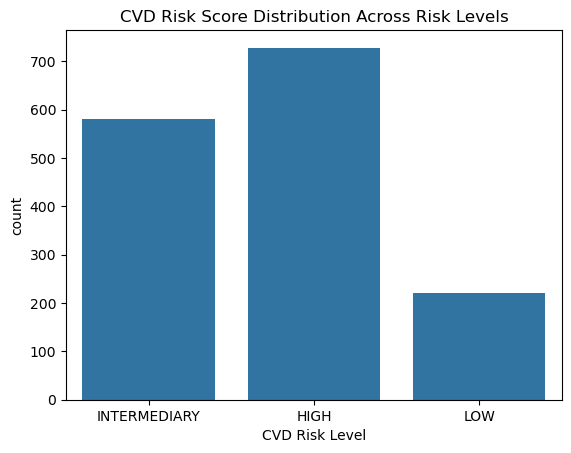

In [13]:
plt.title("CVD Risk Score Distribution Across Risk Levels")
sns.countplot(x="CVD Risk Level", data=df)

In [14]:
df["CVD Risk Level"].value_counts()

CVD Risk Level
HIGH            728
INTERMEDIARY    581
LOW             220
Name: count, dtype: int64

#### Summarized Findings

#### 5.3 Demographic Analysis

In this section, demographic variables such as age and sex are analyzed to examine how the population is distributed and to identify any patterns or differences across groups.

Text(0, 0.5, 'Count')

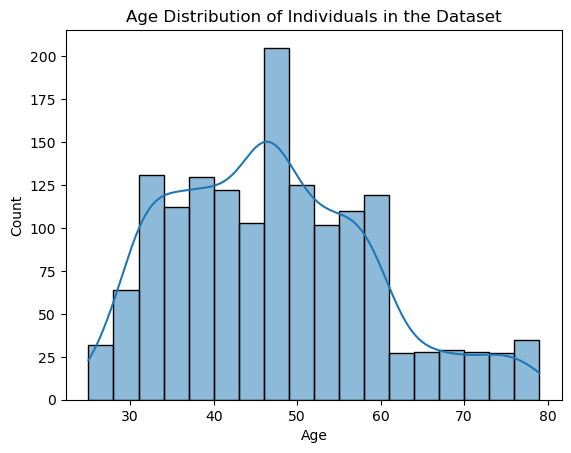

In [15]:
sns.histplot(df["Age"], kde=True)
plt.title("Age Distribution of Individuals in the Dataset")
plt.xlabel("Age")
plt.ylabel("Count")

The histogram shows that most individuals in the dataset are concentrated in the middle-age range (approximately 35–60 years old), with fewer individuals in the younger and older age groups.

<Axes: xlabel='CVD Risk Level', ylabel='Age'>

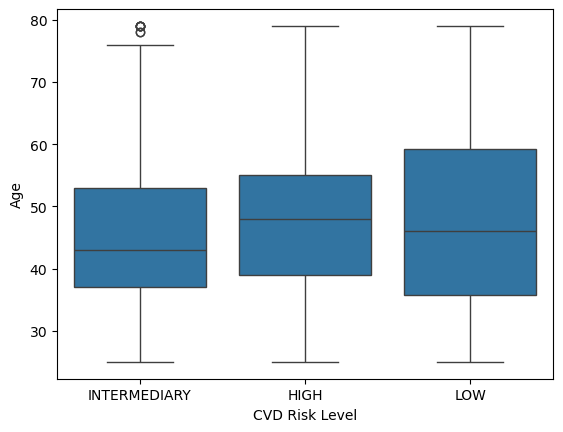

In [16]:
sns.boxplot(x="CVD Risk Level", y="Age", data=df)

The graph shows that individuals in the High CVD Risk group tend to have a slightly higher median age compared to the Intermediary and Low risk groups, suggesting that increasing age may be associated with greater cardiovascular risk.

In [17]:
df["Sex"].value_counts()

Sex
F    773
M    756
Name: count, dtype: int64

There are more females than males in the dataset

<Axes: title={'center': 'Gender Distribution Across CVD Risk Levels'}, xlabel='Sex', ylabel='count'>

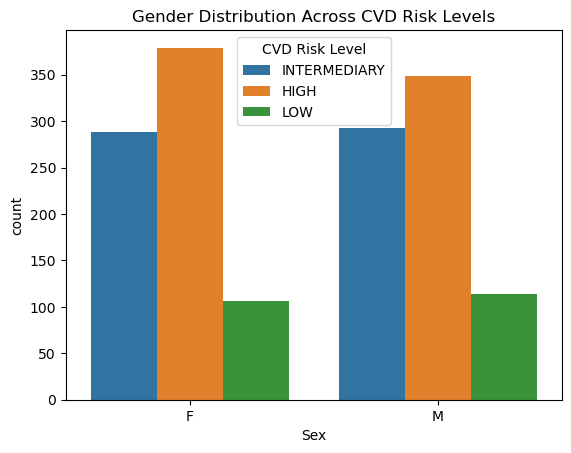

In [18]:
plt.title("Gender Distribution Across CVD Risk Levels")
sns.countplot(x="Sex", hue="CVD Risk Level", data=df)

The graph shows that females are slightly more represented than males in the dataset, which explains the higher counts observed across most CVD risk levels rather than indicating a clear gender-based difference in cardiovascular risk.

#### Summarized Findings

#### 5.4 Categorial Distributions

In this section, categorical variables are examined through frequency distributions and count plots to understand the composition of the dataset and identify general patterns across key lifestyle and health-related factors.

Sex
F    773
M    756
Name: count, dtype: int64
---
Smoking Status
Y    789
N    740
Name: count, dtype: int64
---
Diabetes Status
Y    777
N    752
Name: count, dtype: int64
---
Physical Activity Level
High        521
Moderate    512
Low         496
Name: count, dtype: int64
---
Blood Pressure Category
Hypertension Stage 2    632
Hypertension Stage 1    497
Normal                  300
Elevated                100
Name: count, dtype: int64
---
Family History of CVD
N    780
Y    749
Name: count, dtype: int64
---


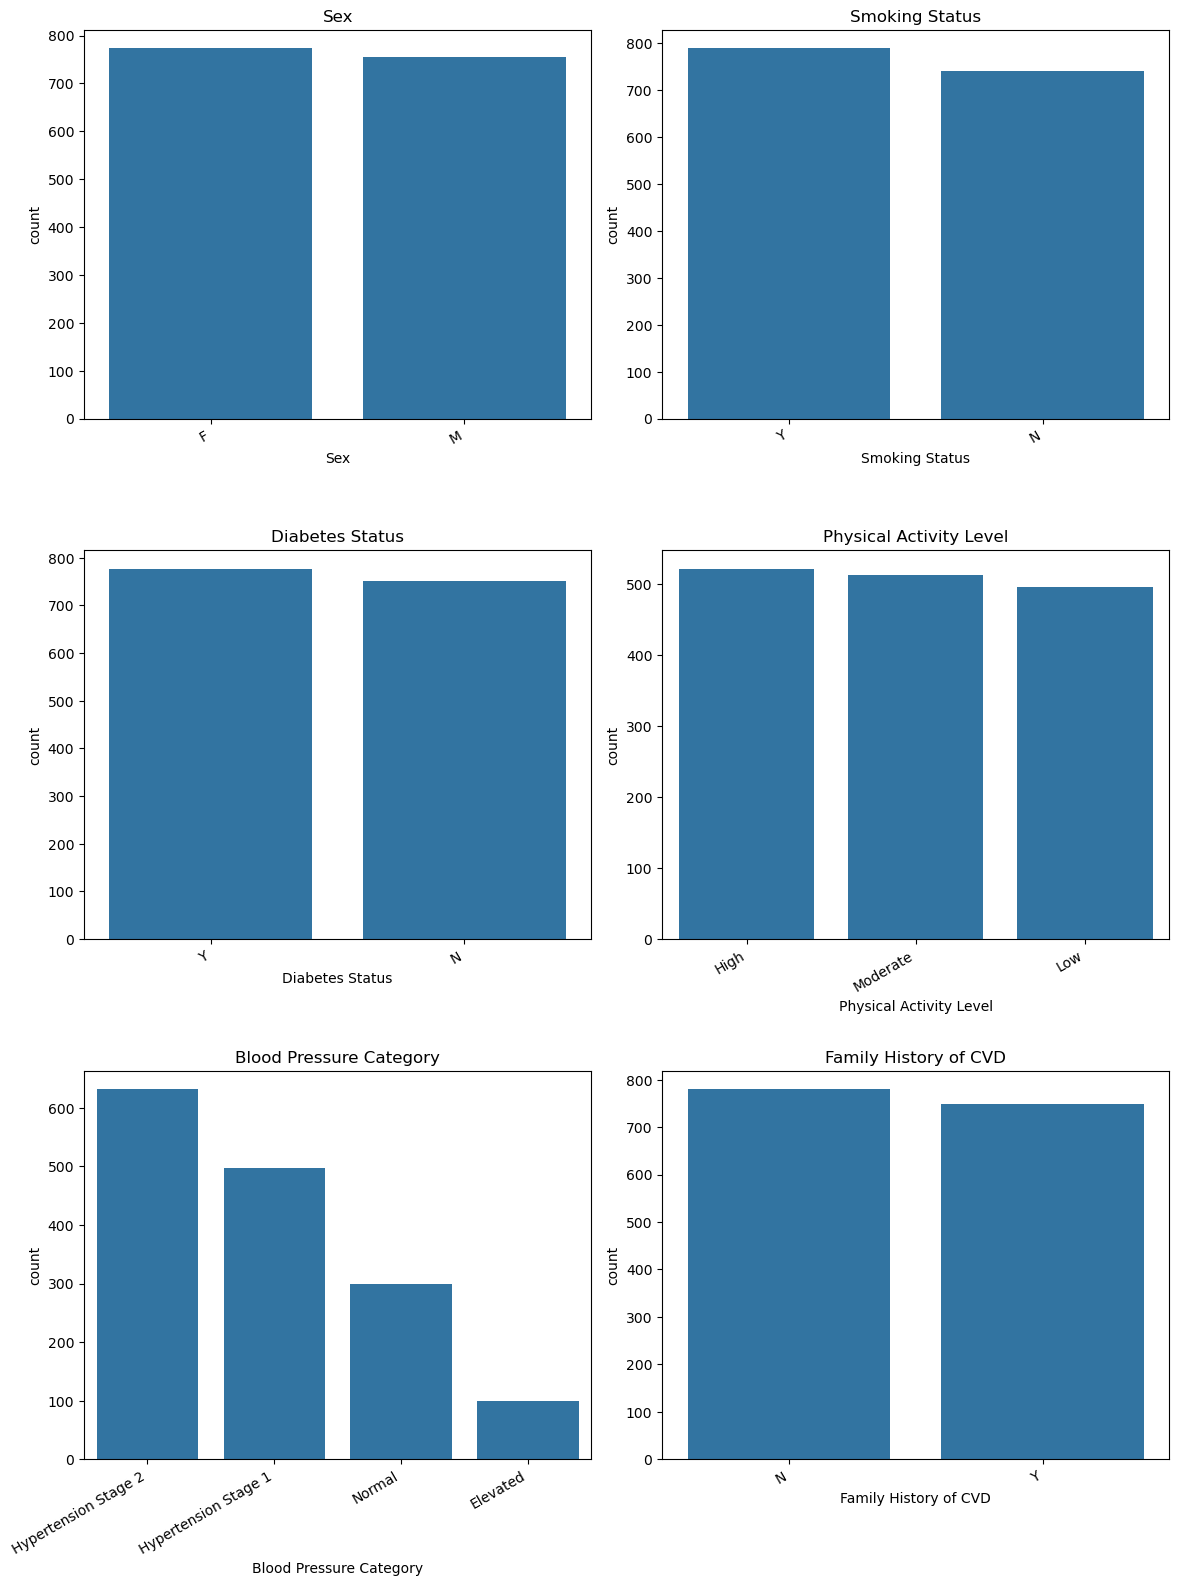

In [19]:
cat_plot_cols = ['Sex','Smoking Status','Diabetes Status','Physical Activity Level','Blood Pressure Category','Family History of CVD']
cat_plot_cols_present = [c for c in cat_plot_cols if c in df.columns]

for col_name in cat_plot_cols_present:
    print(df[col_name].value_counts(dropna=False))
    print('---')

plt.figure(figsize=(12, 20))
for idx, col_name in enumerate(cat_plot_cols_present, start=1):
    plt.subplot(4, 2, idx)
    order_vals = df[col_name].value_counts().index.tolist()
    sns.countplot(data=df, x=col_name, order=order_vals)
    plt.title(col_name)
    plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

#### Summarized Findings

#### 5.5 Body Measurement Analysis

In this section, body measurement variables are explored to understand their distributions and identify patterns or variations in physical characteristics within the dataset.

Text(0, 0.5, 'Count')

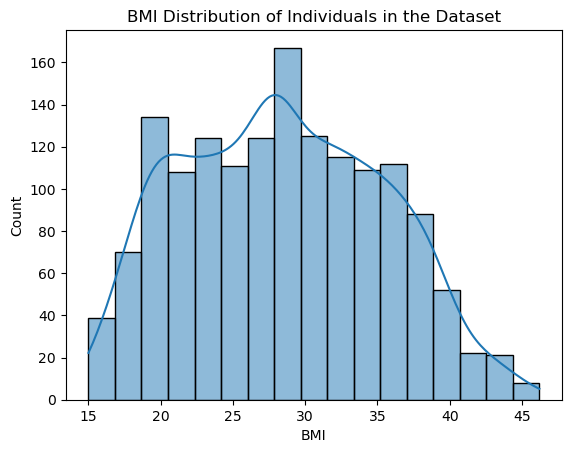

In [20]:
sns.histplot(df["BMI"], kde=True)
plt.title("BMI Distribution of Individuals in the Dataset")
plt.xlabel("BMI")
plt.ylabel("Count")

The BMI distribution is centered around the overweight range (approximately 25–30) with a slight right skew, indicating a higher concentration of individuals with elevated BMI values.

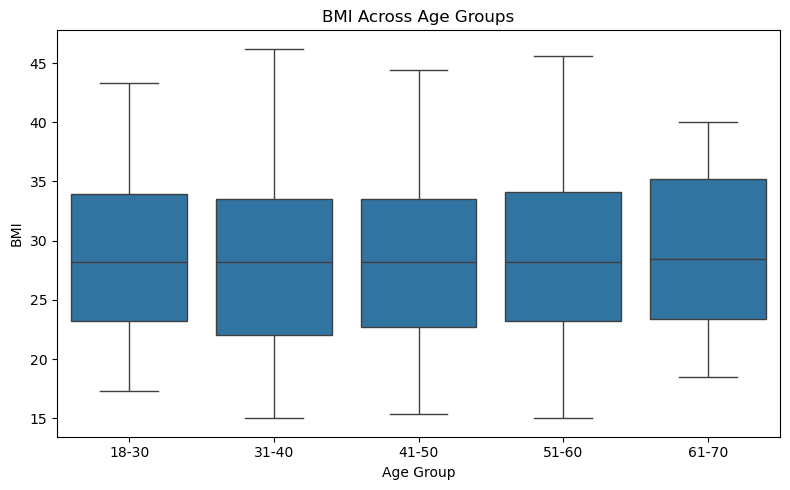

In [21]:
df["Age Group"] = pd.cut(
    df["Age"],
    bins=[18, 30, 40, 50, 60, 70],
    labels=["18-30", "31-40", "41-50", "51-60", "61-70"]
)

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Age Group",
    y="BMI",
    data=df
)

plt.title("BMI Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("BMI")
plt.tight_layout()
plt.show()

BMI shows a slight upward shift in median and upper range with age, with older groups (51–70) having marginally higher and more spread-out BMI compared to younger groups (18–40).

C:\Users\USER\AppData\Local\Temp\ipykernel_10512\1412023386.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weight_trend = df.groupby("Age Group")["Weight (kg)"].mean().reset_index()


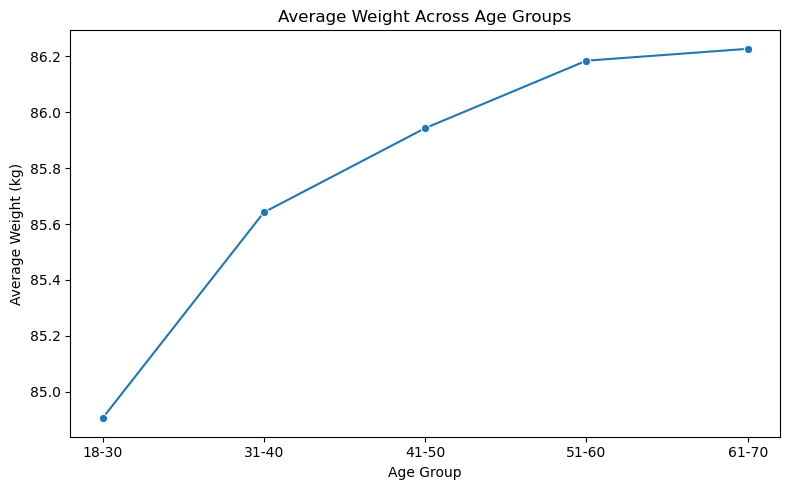

In [22]:
weight_trend = df.groupby("Age Group")["Weight (kg)"].mean().reset_index()

plt.figure(figsize=(8,5))

sns.lineplot(
    x="Age Group",
    y="Weight (kg)",
    data=weight_trend,
    marker="o"
)

plt.title("Average Weight Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Average Weight (kg)")
plt.tight_layout()
plt.show()

Average weight shows a slight increasing trend with age, gradually rising from younger to older age groups.

Text(0.5, 1.0, 'BMI Across CVD Risk Levels')

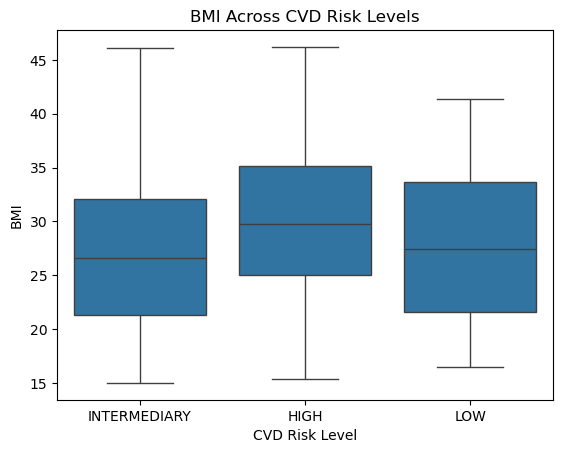

In [23]:
sns.boxplot(x="CVD Risk Level", y="BMI", data=df)
plt.title("BMI Across CVD Risk Levels")

BMI is generally higher in the high CVD risk group, but there is significant overlap across all risk levels.

Text(0.5, 1.0, 'BMI vs Waist-to-Height Ratio by CVD Risk Level')

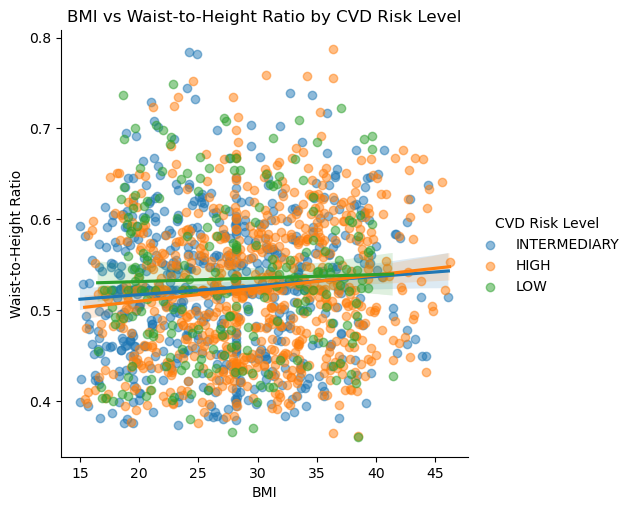

In [24]:
sns.lmplot(
    x="BMI",
    y="Waist-to-Height Ratio",
    hue="CVD Risk Level",
    data=df,
    scatter_kws={"alpha":0.5}
)
plt.title("BMI vs Waist-to-Height Ratio by CVD Risk Level")

Text(0.5, 1.0, 'Waist-to-Height Ratio Across CVD Risk Levels')

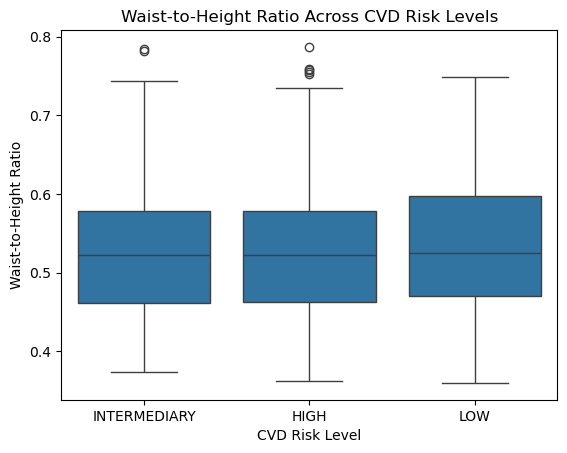

In [25]:
sns.boxplot(x="CVD Risk Level", y="Waist-to-Height Ratio", data=df)
plt.title("Waist-to-Height Ratio Across CVD Risk Levels")

Waist-to-height ratio is very similar across all CVD risk levels, with only a slight increase in the HIGH group, but overall differences are minimal and heavily overlapping.

#### Summarized Findings

#### 5.6 Lifestyle and Health Factors

In this section, lifestyle and health-related factors are analyzed to examine how behaviors and conditions vary across different groups and potentially relate to overall health outcomes.

C:\Users\USER\AppData\Local\Temp\ipykernel_10512\3942097939.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Age Group")["Physical Activity Level"]


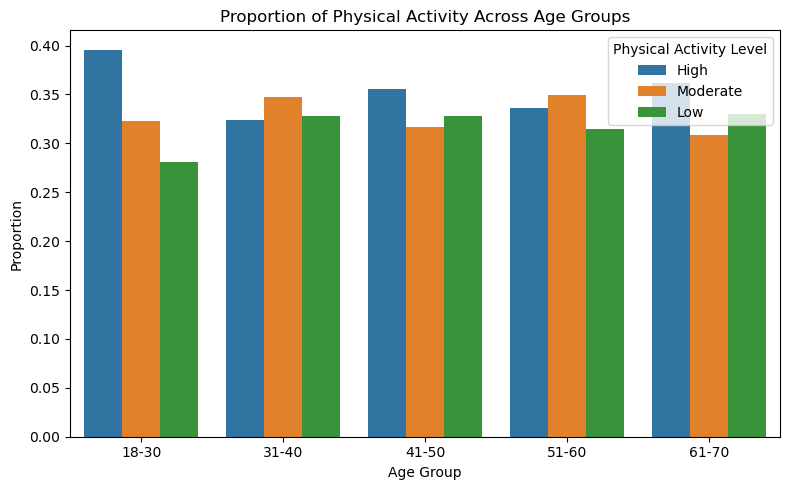

In [26]:
activity_prop = (
    df.groupby("Age Group")["Physical Activity Level"]
    .value_counts(normalize=True)
    .rename("Proportion")
    .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    x="Age Group",
    y="Proportion",
    hue="Physical Activity Level",
    data=activity_prop
)

plt.title("Proportion of Physical Activity Across Age Groups")
plt.tight_layout()
plt.show()

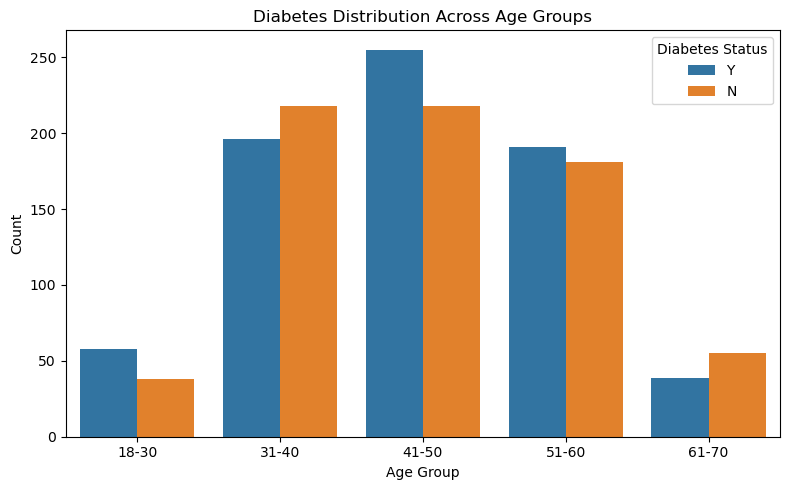

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Age Group",
    hue="Diabetes Status", 
    data=df
)

plt.title("Diabetes Distribution Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Proportion')

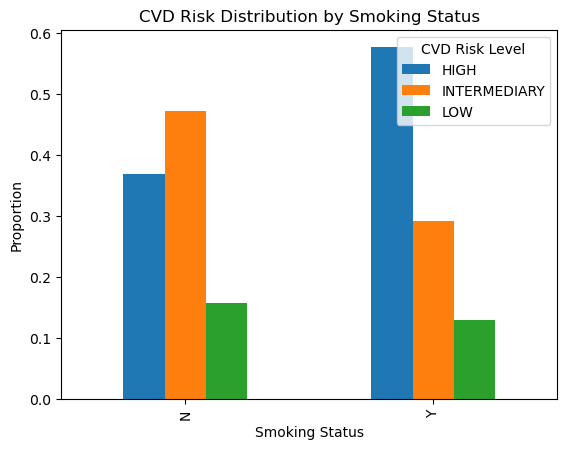

In [28]:
smoking_risk = pd.crosstab(df["Smoking Status"], df["CVD Risk Level"], normalize="index")

smoking_risk.plot(kind="bar", stacked=False)
plt.title("CVD Risk Distribution by Smoking Status")
plt.ylabel("Proportion")

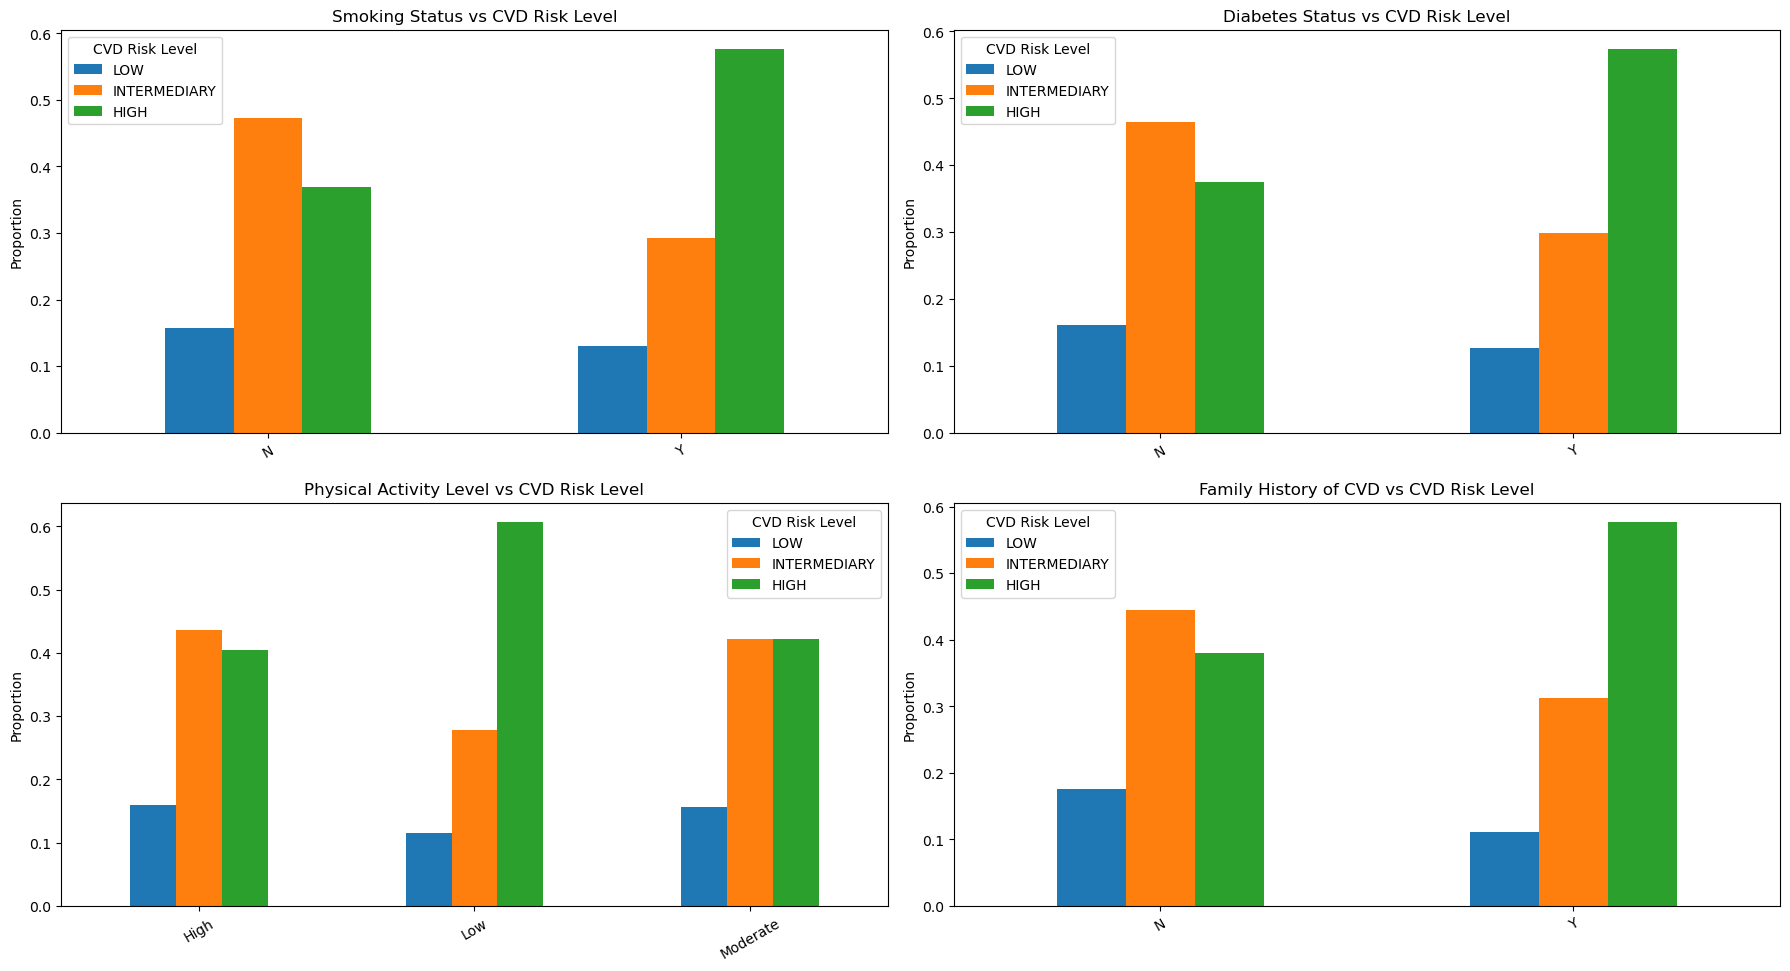


Smoking Status
CVD Risk Level   HIGH  INTERMEDIARY    LOW
Smoking Status                            
N               0.369         0.473  0.158
Y               0.577         0.293  0.131

Diabetes Status
CVD Risk Level    HIGH  INTERMEDIARY    LOW
Diabetes Status                            
N                0.375         0.464  0.161
Y                0.574         0.299  0.127

Physical Activity Level
CVD Risk Level            HIGH  INTERMEDIARY    LOW
Physical Activity Level                            
High                     0.405         0.436  0.159
Low                      0.607         0.278  0.115
Moderate                 0.422         0.422  0.156

Family History of CVD
CVD Risk Level          HIGH  INTERMEDIARY    LOW
Family History of CVD                            
N                      0.379         0.445  0.176
Y                      0.577         0.312  0.111


In [29]:
risk_order = ['LOW', 'INTERMEDIARY', 'HIGH']

cat_vars = [
    'Smoking Status',
    'Diabetes Status',
    'Physical Activity Level',
    'Family History of CVD'
]

cat_vars_present = [col for col in cat_vars if col in df.columns]

plt.figure(figsize=(18, 14))

for i, col in enumerate(cat_vars_present, 1):
    plt.subplot(3, 2, i)
    
    ctab = pd.crosstab(df[col], df['CVD Risk Level'], normalize='index')
    ctab = ctab.reindex(columns=risk_order)
    
    ctab.plot(kind='bar', stacked=False, ax=plt.gca())
    
    plt.title(f'{col} vs CVD Risk Level')
    plt.xlabel('')
    plt.ylabel('Proportion')
    plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

for col in cat_vars_present:
    print(f"\n{col}")
    print(pd.crosstab(df[col], df['CVD Risk Level'], normalize='index').round(3))

#### Summarized Findings

#### 5.7 Clinical indicators

#### Blood Pressure

In this section, clinical indicators are analyzed to assess their distributions and observe how they vary across different CVD risk levels.

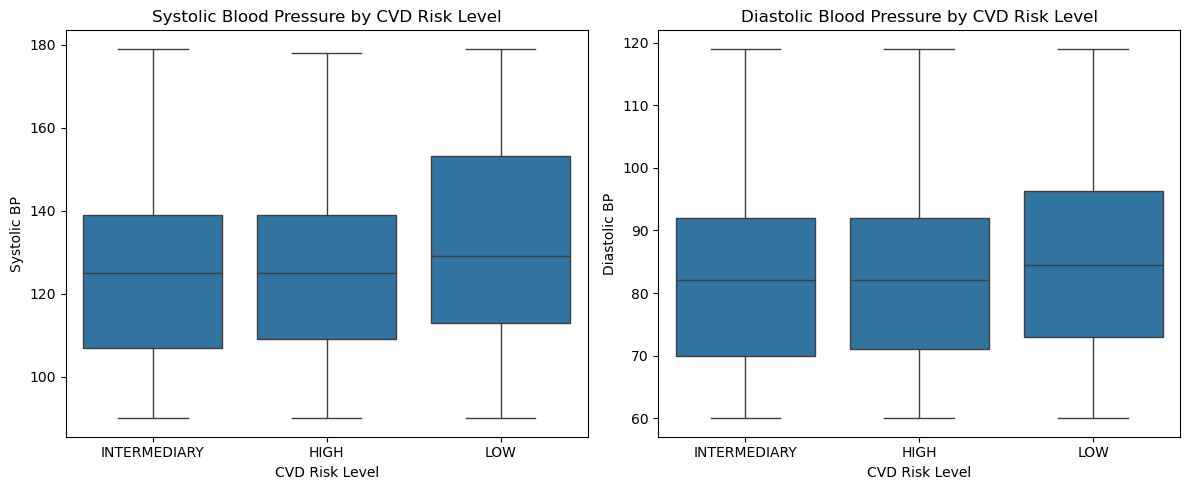

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Systolic BP
sns.boxplot(
    x="CVD Risk Level",
    y="Systolic BP",
    data=df,
    ax=axes[0]
)
axes[0].set_title("Systolic Blood Pressure by CVD Risk Level")

# Diastolic BP
sns.boxplot(
    x="CVD Risk Level",
    y="Diastolic BP",
    data=df,
    ax=axes[1]
)
axes[1].set_title("Diastolic Blood Pressure by CVD Risk Level")

plt.tight_layout()
plt.show()

Both systolic and diastolic blood pressure show a slight increase in median and variability in higher CVD risk groups, but with considerable overlap across all levels.

#### Cholesterol Profile

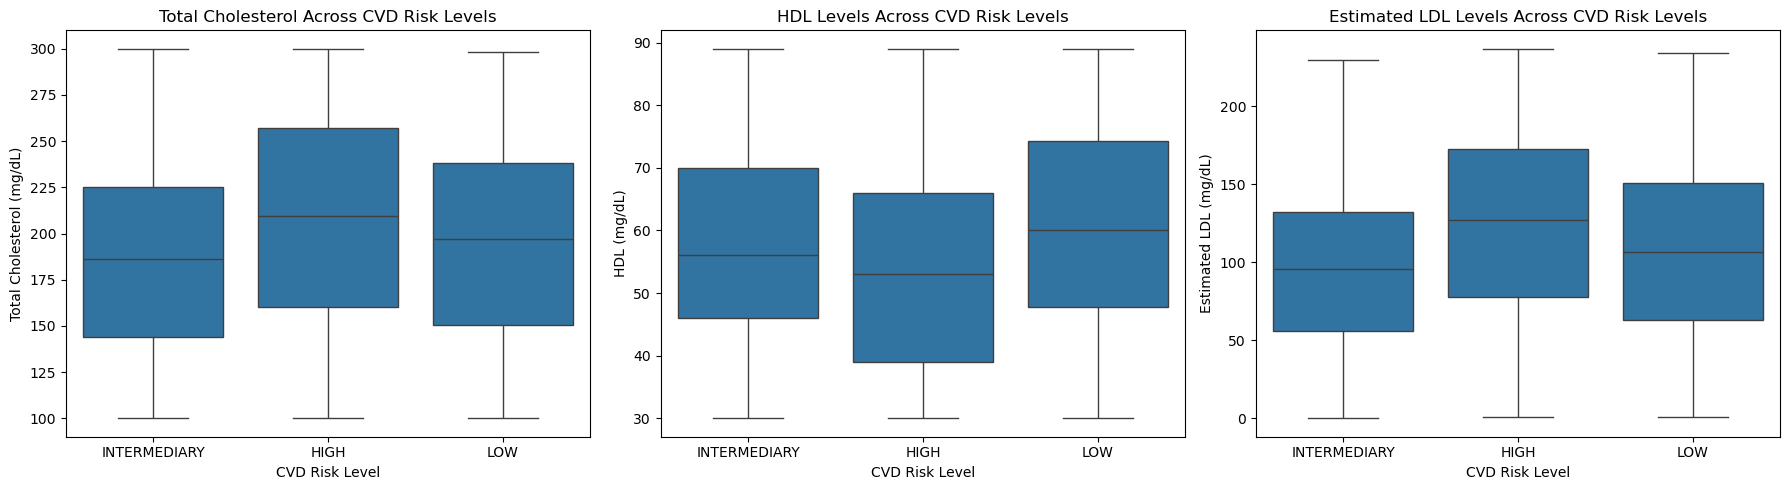

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.boxplot(x="CVD Risk Level", y="Total Cholesterol (mg/dL)", data=df, ax=axes[0])
axes[0].set_title("Total Cholesterol Across CVD Risk Levels")

sns.boxplot(x="CVD Risk Level", y="HDL (mg/dL)", data=df, ax=axes[1])
axes[1].set_title("HDL Levels Across CVD Risk Levels")

sns.boxplot(x="CVD Risk Level", y="Estimated LDL (mg/dL)", data=df, ax=axes[2])
axes[2].set_title("Estimated LDL Levels Across CVD Risk Levels")

plt.tight_layout()
plt.show()

Higher CVD risk is generally associated with increased total cholesterol and LDL and slightly lower HDL, although substantial overlap between groups indicates these markers alone do not fully distinguish risk levels.


#### Blood Sugar

Text(0, 0.5, 'Fasting Blood Sugar (mg/dL)')

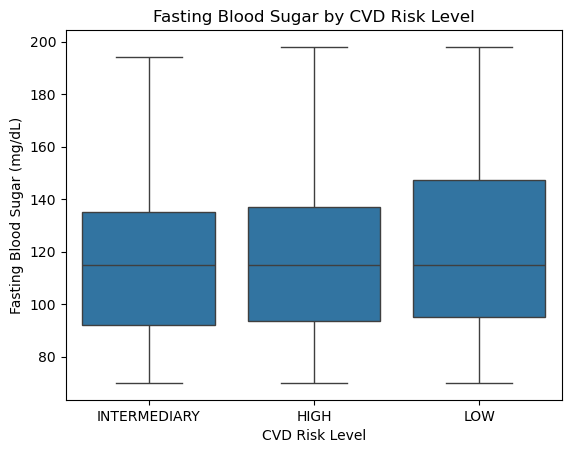

In [32]:
sns.boxplot(
    x="CVD Risk Level",
    y="Fasting Blood Sugar (mg/dL)",
    data=df
)

plt.title("Fasting Blood Sugar by CVD Risk Level")
plt.xlabel("CVD Risk Level")
plt.ylabel("Fasting Blood Sugar (mg/dL)")

Fasting blood sugar levels are fairly similar across all CVD risk groups, with only slight increases in variability at higher risk levels

#### Summarized Findings

#### 5.8 Correlation Heatmap of Numerical Features

Text(0.5, 1.0, 'Correlation Heatmap of Numerical Features')

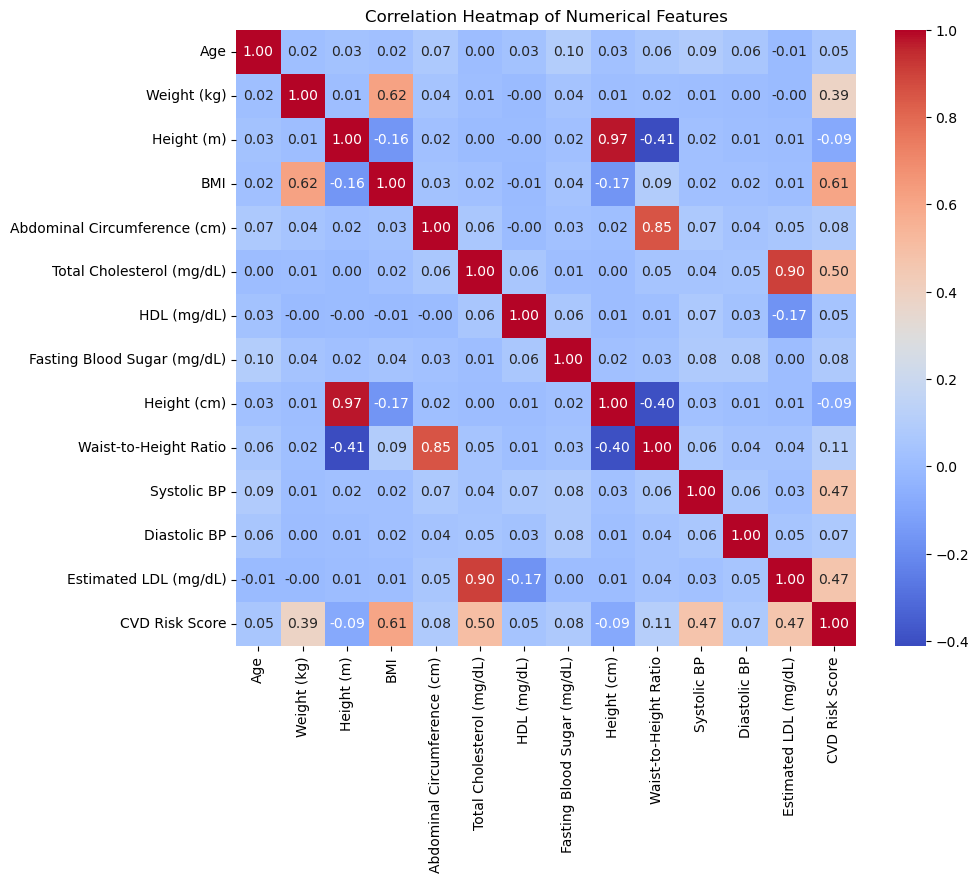

In [33]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Features")

#### Summarized Findings

#### 5.9 EDA Conclusions

* **Note:** Age Group was engineered solely for EDA visualization and was removed before modeling since it is derived from Age and introduces redundancy.

In [34]:
df = df.drop(columns=['Age Group'])

# Section 6. Model Training

#### 6.1 Feature Selection

Statistical tests are used to evaluate whether each feature is significantly associated with the target variable (CVD Risk Level). For numerical features, a one-way ANOVA test is applied to determine whether the mean values differ significantly across the three risk groups (LOW, INTERMEDIARY, HIGH). For categorical features, the Chi-square test of independence is used to assess whether there is a significant relationship between each feature and the target variable.

In [35]:
numerical_features = [
    'Age',
    'BMI',
    'Height (cm)',
    'Abdominal Circumference (cm)',
    'Waist-to-Height Ratio',
    'Systolic BP',
    'Diastolic BP',
    'Total Cholesterol (mg/dL)',
    'HDL (mg/dL)',
    'Estimated LDL (mg/dL)',
    'Fasting Blood Sugar (mg/dL)',
]
categorical_features = [
    'Sex',
    'Smoking Status',
    'Diabetes Status',
    'Physical Activity Level',
    'Family History of CVD'
]
target = 'CVD Risk Level'

#### ANOVA Test for Numerical Features

In [36]:
anova_results = []

for feature in numerical_features:
    low = df[df[target] == 'LOW'][feature].dropna()
    medium = df[df[target] == 'INTERMEDIARY'][feature].dropna()
    high = df[df[target] == 'HIGH'][feature].dropna()
    
    f_stat, p_value = f_oneway(low, medium, high)
    
    anova_results.append({
        'Feature': feature,
        'Test': 'ANOVA',
        'Statistic': round(f_stat, 4),
        'p-value': round(p_value, 6),
        'Significant': 'Yes' if p_value < 0.05 else 'No'
    })

anova_df = pd.DataFrame(anova_results)
anova_df

,Feature,Test,Statistic,p-value,Significant
0,Age,ANOVA,5.6595,0.003558,Yes
1,BMI,ANOVA,28.0091,0.000000,Yes
2,Height (cm),ANOVA,2.0385,0.130576,No
3,Abdominal Circumference (cm),ANOVA,1.7646,0.171597,No
4,Waist-to-Height Ratio,ANOVA,1.6391,0.194487,No
5,Systolic BP,ANOVA,12.1010,0.000006,Yes
6,Diastolic BP,ANOVA,6.5150,0.001523,Yes
7,Total Cholesterol (mg/dL),ANOVA,22.0504,0.000000,Yes
8,HDL (mg/dL),ANOVA,24.3644,0.000000,Yes
9,Estimated LDL (mg/dL),ANOVA,35.7582,0.000000,Yes


#### Chi-Square Test for Categorical Features

In [37]:
chi_results = []

for feature in categorical_features:
    table = pd.crosstab(df[feature], df[target])
    chi2, p_value, dof, expected = chi2_contingency(table)
    
    chi_results.append({
        'Feature': feature,
        'Test': 'Chi-square',
        'Statistic': round(chi2, 4),
        'p-value': round(p_value, 6),
        'Significant': 'Yes' if p_value < 0.05 else 'No'
    })

chi_df = pd.DataFrame(chi_results)
chi_df

,Feature,Test,Statistic,p-value,Significant
0,Sex,Chi-square,1.3814,0.501235,No
1,Smoking Status,Chi-square,69.2652,0.000000,Yes
2,Diabetes Status,Chi-square,62.3141,0.000000,Yes
3,Physical Activity Level,Chi-square,50.9401,0.000000,Yes
4,Family History of CVD,Chi-square,60.0349,0.000000,Yes


Feature testing using ANOVA (for numerical variables) and Chi-square (for categorical variables) was performed to identify which features are significantly associated with CVD Risk Level. This ensures that only relevant variables are used for model training.

#### Dropping of features

In [38]:
df = df.drop(columns=["Sex", "Height (cm)", "Blood Pressure (mmHg)", "Abdominal Circumference (cm)", "Total Cholesterol (mg/dL)", "Waist-to-Height Ratio", "Height (m)", "Blood Pressure Category", "CVD Risk Score"])

In [39]:
print("Remaining columns after dropping:")
for col in df.columns:
    if col not in ['CVD Risk Level']:
        print("Feature:", col)

print("\nLabel:", 'CVD Risk Level')

Remaining columns after dropping:
Feature: Age
Feature: Weight (kg)
Feature: BMI
Feature: HDL (mg/dL)
Feature: Fasting Blood Sugar (mg/dL)
Feature: Smoking Status
Feature: Diabetes Status
Feature: Physical Activity Level
Feature: Family History of CVD
Feature: Systolic BP
Feature: Diastolic BP
Feature: Estimated LDL (mg/dL)

Label: CVD Risk Level


The features **Blood Pressure Category** and **CVD Risk Score** were removed from the dataset 
before model training. These variables are directly related to the target variable 
**CVD Risk Level**, which the model is intended to predict.

Including **CVD Risk Score** would allow the model to effectively *cheat*, since the 
risk level is derived from this score. The model could simply learn rules 
such as *if risk score > 15 → High risk* instead of learning the underlying relationships 
between the health indicators (e.g., blood pressure, cholesterol, BMI) and cardiovascular risk.

Furthermore, Total Cholesterol was removed due to its high correlation with Estimated LDL (r ≈ 0.90) and its nature as an aggregate lipid measure. Instead of using a combined indicator, the model retains individual lipid components (e.g., LDL and HDL), allowing it to learn more granular and clinically meaningful relationships. This is also to avoid redundancy in our dataset

Additionally, the feature Blood Pressure (mmHg) was excluded due to redundancy. This variable represents a combined measurement of systolic and diastolic pressure (e.g., “120/80”), which are already included as separate numerical features (Systolic BP and Diastolic BP)

To ensure that the model learns meaningful physiological patterns rather than relying on 
derived labels, these variables were excluded from the feature set.

#### 6.2 Feature Encoding

In this section, categorical features are transformed into numerical representations to make them suitable for machine learning models. Binary variables such as smoking status, diabetes status, and family history of cardiovascular disease are encoded using binary mapping (Yes = 1, No = 0). Additionally, ordinal encoding is applied to the Physical Activity Level feature, where categories are mapped according to their natural order (Low < Moderate < High).

Ordinal Mapping

In [40]:
binary_cols = ['Smoking Status', 'Diabetes Status', 'Family History of CVD']

for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].map({'Y': 1, 'N': 0})

In [41]:
activity_map = {
    'Low': 0,
    'Moderate': 1,
    'High': 2
}
df['Physical Activity Level'] = df['Physical Activity Level'].map(activity_map)

#### 6.3 Train/Test/Validation Split

The dataset was split into training, test, and validation sets using a **70:15:15 ratio**, respectively. Stratified sampling is applied to maintain the class distribution of the target variable across all subsets, allowing for reliable model training, tuning, and evaluation.

In [42]:
X = df.drop(['CVD Risk Level'], axis=1, errors='ignore')
y = df['CVD Risk Level']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (1529, 12)
Shape of y: (1529,)


In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

In [44]:
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=1, stratify=y_test)

In [45]:
print("Training set shape (X,y):", X_train.shape, y_train.shape)
print("Test set shape (X,y):", X_test.shape, y_test.shape)
print("Validation set shape (X,y):", X_val.shape, y_val.shape)

Training set shape (X,y): (1070, 12) (1070,)
Test set shape (X,y): (229, 12) (229,)
Validation set shape (X,y): (230, 12) (230,)


#### 6.4 Scaling

In this section, feature scaling is performed using StandardScaler to normalize the input variables. The scaler is fitted on the training set and applied to the validation and test sets to ensure consistency and prevent data leakage.

In [46]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

#### 6.5.1 KNN

Helper function to evaluate model accuracy 

In [47]:
def evaluate(name, y_true, y_pred):
    print(f"\n{name} RESULTS")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(classification_report(y_true, y_pred))

In [48]:
model = KNeighborsClassifier(n_neighbors=3)

In [49]:
model.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=3)

In [50]:
y_predicted_train = model.predict(X_train_scaled)
y_predicted_test = model.predict(X_test_scaled)
y_predicted_val = model.predict(X_val_scaled)

evaluate("TRAIN", y_train, y_predicted_train)
evaluate("TEST", y_test, y_predicted_test)
evaluate("VALIDATION", y_val, y_predicted_val)


TRAIN RESULTS
Accuracy: 0.7897
              precision    recall  f1-score   support

        HIGH       0.78      0.90      0.83       509
INTERMEDIARY       0.81      0.82      0.81       407
         LOW       0.74      0.36      0.49       154

    accuracy                           0.79      1070
   macro avg       0.78      0.69      0.71      1070
weighted avg       0.79      0.79      0.78      1070


TEST RESULTS
Accuracy: 0.5939
              precision    recall  f1-score   support

        HIGH       0.61      0.74      0.67       109
INTERMEDIARY       0.62      0.60      0.61        87
         LOW       0.25      0.09      0.13        33

    accuracy                           0.59       229
   macro avg       0.49      0.48      0.47       229
weighted avg       0.56      0.59      0.57       229


VALIDATION RESULTS
Accuracy: 0.5826
              precision    recall  f1-score   support

        HIGH       0.62      0.71      0.66       110
INTERMEDIARY       0.54      

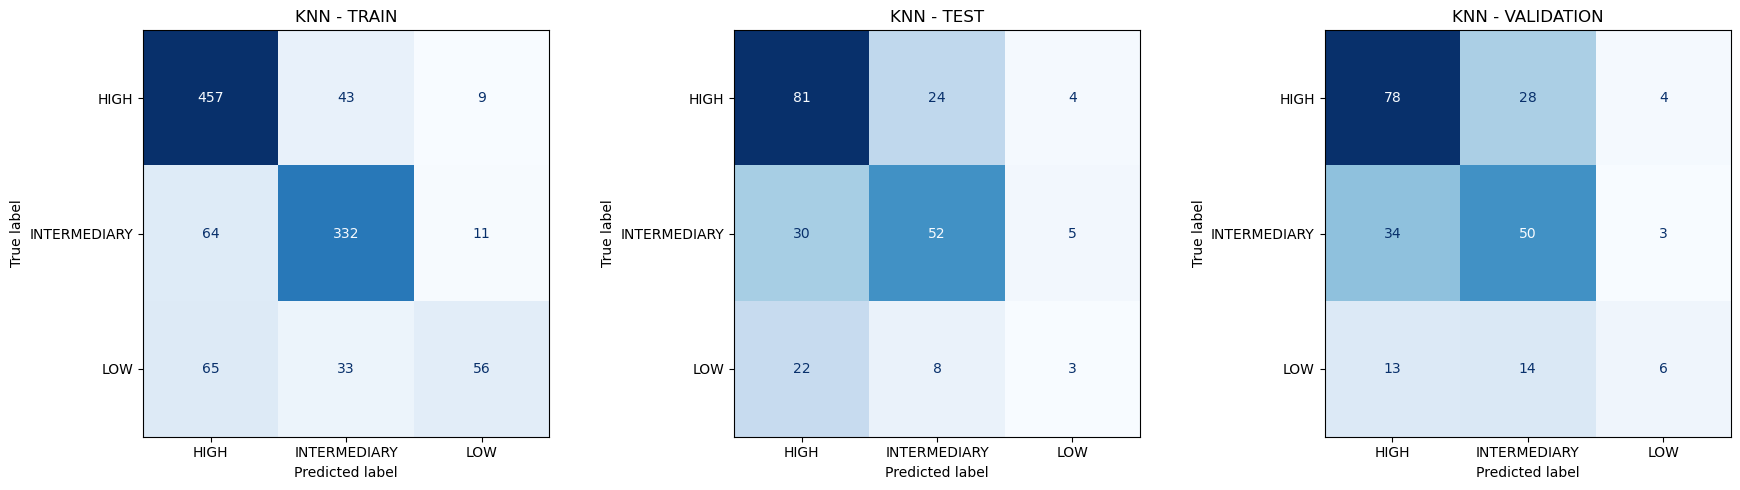

In [51]:
cm_train = confusion_matrix(y_train, y_predicted_train)
cm_test = confusion_matrix(y_test, y_predicted_test)
cm_val = confusion_matrix(y_val, y_predicted_val)

labels = ['HIGH', 'INTERMEDIARY', 'LOW']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, cm, title in zip(
    axes,
    [cm_train, cm_test, cm_val],
    ["TRAIN", "TEST", "VALIDATION"]
):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"KNN - {title}")

plt.tight_layout()
plt.show()

KNN achieved higher training accuracy (~0.79) but dropped significantly on test and validation (~0.58–0.59), indicating overfitting and limited generalization. The model performs well for HIGH and INTERMEDIARY classes but struggles to correctly identify LOW cases, frequently misclassifying them as higher risk levels.

#### 6.5.2 Logistic Regression

In [52]:
model = SGDClassifier(
    loss='log_loss',
    alpha=0.0001,
    max_iter=2000,
    tol=1e-4,
    class_weight='balanced',
    random_state=42
)

In [53]:
model.fit(X_train_scaled, y_train)

SGDClassifier(class_weight='balanced', loss='log_loss', max_iter=2000,
              random_state=42, tol=0.0001)

In [54]:
y_predicted_train = model.predict(X_train_scaled)
y_predicted_test = model.predict(X_test_scaled)
y_predicted_val = model.predict(X_val_scaled)

evaluate("TRAIN", y_train, y_predicted_train)
evaluate("TEST", y_test, y_predicted_test)
evaluate("VALIDATION", y_val, y_predicted_val)


TRAIN RESULTS
Accuracy: 0.6364
              precision    recall  f1-score   support

        HIGH       0.72      0.72      0.72       509
INTERMEDIARY       0.61      0.68      0.64       407
         LOW       0.34      0.23      0.28       154

    accuracy                           0.64      1070
   macro avg       0.56      0.55      0.55      1070
weighted avg       0.62      0.64      0.63      1070


TEST RESULTS
Accuracy: 0.5852
              precision    recall  f1-score   support

        HIGH       0.70      0.72      0.71       109
INTERMEDIARY       0.54      0.57      0.56        87
         LOW       0.23      0.18      0.20        33

    accuracy                           0.59       229
   macro avg       0.49      0.49      0.49       229
weighted avg       0.57      0.59      0.58       229


VALIDATION RESULTS
Accuracy: 0.5913
              precision    recall  f1-score   support

        HIGH       0.69      0.67      0.68       110
INTERMEDIARY       0.55      

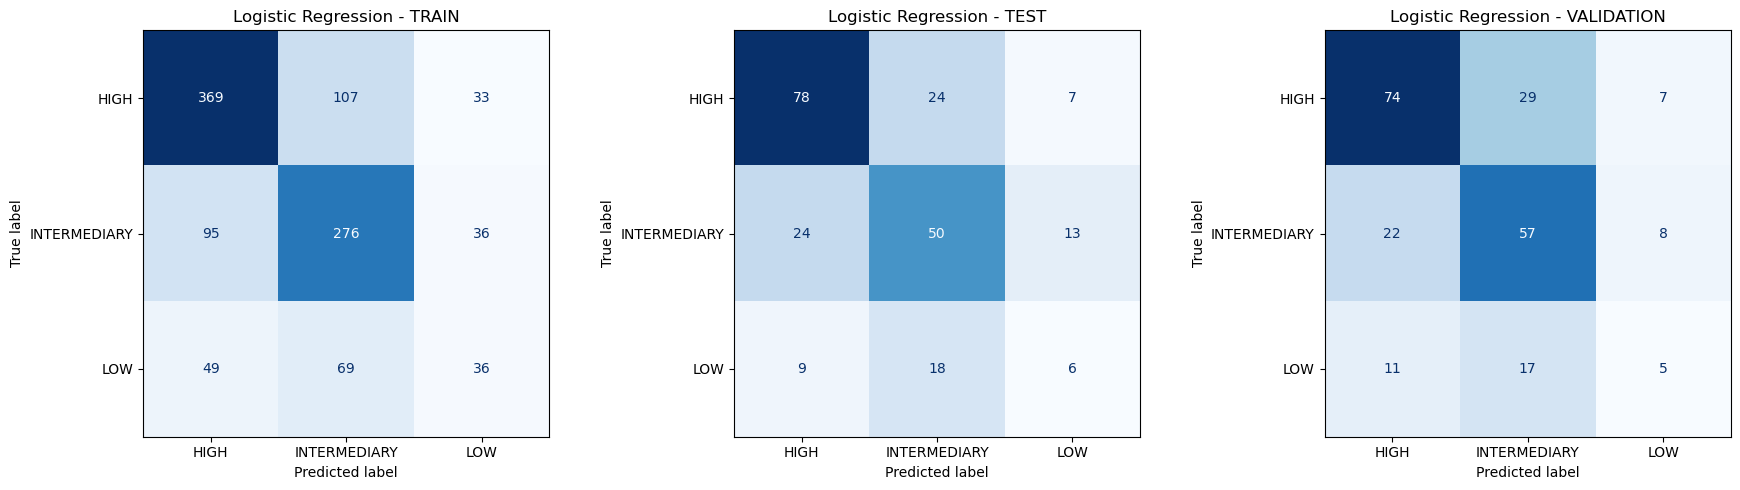

In [55]:
cm_train = confusion_matrix(y_train, y_predicted_train)
cm_test = confusion_matrix(y_test, y_predicted_test)
cm_val = confusion_matrix(y_val, y_predicted_val)

labels = ['HIGH', 'INTERMEDIARY', 'LOW']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, cm, title in zip(
    axes,
    [cm_train, cm_test, cm_val],
    ["TRAIN", "TEST", "VALIDATION"]
):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"Logistic Regression - {title}")

plt.tight_layout()
plt.show()

Logistic Regression shows more consistent performance across training, test, and validation sets (~0.56–0.64 accuracy), indicating better generalization and less overfitting compared to KNN. However, it still struggles with the LOW class, frequently misclassifying it as INTERMEDIARY, suggesting overlap between these classes and the effect of class imbalance.

#### 6.5.3 Neural Network

In this section, we implement a Neural Network using sklearn's `MLPClassifier` to predict **CVD Risk Level** (LOW, INTERMEDIARY, HIGH).

The model is a Multilayer Perceptron (MLP), which consists of:
- Input layer (features)
- One or two hidden layers
- Output layer (3 classes)

We experiment with different architectures and hyperparameters to determine the best-performing model.

In [56]:
from sklearn.neural_network import MLPClassifier

label_map = {
    'HIGH': 0,
    'INTERMEDIARY': 1,
    'LOW': 2
}

y_train_enc = y_train.map(label_map)
y_val_enc = y_val.map(label_map)
y_test_enc = y_test.map(label_map)

class_names = ['HIGH', 'INTERMEDIARY', 'LOW']

#### Model Evaluation Function

We define a helper function to evaluate each neural network configuration.

In [57]:
def evaluate_model(name, model, X_tr, y_tr, X_vl, y_vl):
    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_vl)

    acc = accuracy_score(y_vl, y_pred)

    print("=" * 50)
    print(f"Model: {name}")
    print(f"Validation Accuracy: {acc:.4f}\n")

    print(classification_report(y_vl, y_pred, target_names=class_names, digits=4))
    print("Confusion Matrix:")
    print(confusion_matrix(y_vl, y_pred))
    print()

    return acc

#### Training Multiple Configurations (Initial Manual Tuning)

In [58]:
configs = [
    ("(32,), lr=0.001", (32,), 0.001, 500),
    ("(32,), lr=0.01", (32,), 0.01, 500),
    ("(64,32), lr=0.001", (64,32), 0.001, 500),
    ("(64,32), lr=0.01", (64,32), 0.01, 500),
]

results = {}

for name, layers, lr, iters in configs:
    model = MLPClassifier(
        hidden_layer_sizes=layers,
        learning_rate_init=lr,
        max_iter=iters,
        activation='relu',
        solver='adam',
        early_stopping=True,
        random_state=42
    )

    acc = evaluate_model(
        name,
        model,
        X_train_scaled,
        y_train_enc,
        X_val_scaled,
        y_val_enc
    )

    results[name] = acc

Model: (32,), lr=0.001
Validation Accuracy: 0.6130

              precision    recall  f1-score   support

        HIGH     0.6613    0.7455    0.7009       110
INTERMEDIARY     0.5566    0.6782    0.6114        87
         LOW     0.0000    0.0000    0.0000        33

    accuracy                         0.6130       230
   macro avg     0.4060    0.4745    0.4374       230
weighted avg     0.5268    0.6130    0.5665       230

Confusion Matrix:
[[82 28  0]
 [28 59  0]
 [14 19  0]]

Model: (32,), lr=0.01
Validation Accuracy: 0.5913

              precision    recall  f1-score   support

        HIGH     0.6667    0.7091    0.6872       110
INTERMEDIARY     0.5481    0.6552    0.5969        87
         LOW     0.1111    0.0303    0.0476        33

    accuracy                         0.5913       230
   macro avg     0.4420    0.4649    0.4439       230
weighted avg     0.5421    0.5913    0.5613       230

Confusion Matrix:
[[78 27  5]
 [27 57  3]
 [12 20  1]]

Model: (64,32), lr=0.00

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Model: (64,32), lr=0.01
Validation Accuracy: 0.6391

              precision    recall  f1-score   support

        HIGH     0.6772    0.7818    0.7257       110
INTERMEDIARY     0.6000    0.6207    0.6102        87
         LOW     0.5385    0.2121    0.3043        33

    accuracy                         0.6391       230
   macro avg     0.6052    0.5382    0.5468       230
weighted avg     0.6281    0.6391    0.6216       230

Confusion Matrix:
[[86 23  1]
 [28 54  5]
 [13 13  7]]



Neural networks show comparable accuracy (~0.59–0.64) to previous models with relatively stable performance across configurations, indicating decent generalization. However, similar to logistic regression, they still struggle with the LOW class, often misclassifying it as INTERMEDIARY, highlighting persistent class overlap and imbalance issues.

#### Best Model Selection

In this section, the best neural network model is selected by comparing validation accuracies across different configurations. The model with the highest validation accuracy is chosen, indicating the best generalization performance. In this case, the (64, 32) architecture with a learning rate of 0.01 performed best.

In [59]:
best_model_name = max(results, key=results.get)

print("Best Model:", best_model_name)
print("Best Validation Accuracy:", results[best_model_name])

Best Model: (64,32), lr=0.01
Best Validation Accuracy: 0.6391304347826087


#### Final Model Evaluation

We retrain the best configuration and evaluate its performance on the validation set.


TRAIN RESULTS
Accuracy: 0.7355
              precision    recall  f1-score   support

           0       0.76      0.87      0.81       509
           1       0.71      0.77      0.74       407
           2       0.65      0.21      0.32       154

    accuracy                           0.74      1070
   macro avg       0.71      0.62      0.62      1070
weighted avg       0.73      0.74      0.71      1070


TEST RESULTS
Accuracy: 0.6288
              precision    recall  f1-score   support

           0       0.68      0.75      0.71       109
           1       0.58      0.66      0.62        87
           2       0.50      0.15      0.23        33

    accuracy                           0.63       229
   macro avg       0.59      0.52      0.52       229
weighted avg       0.62      0.63      0.61       229


VALIDATION RESULTS
Accuracy: 0.6391
              precision    recall  f1-score   support

           0       0.68      0.78      0.73       110
           1       0.60      

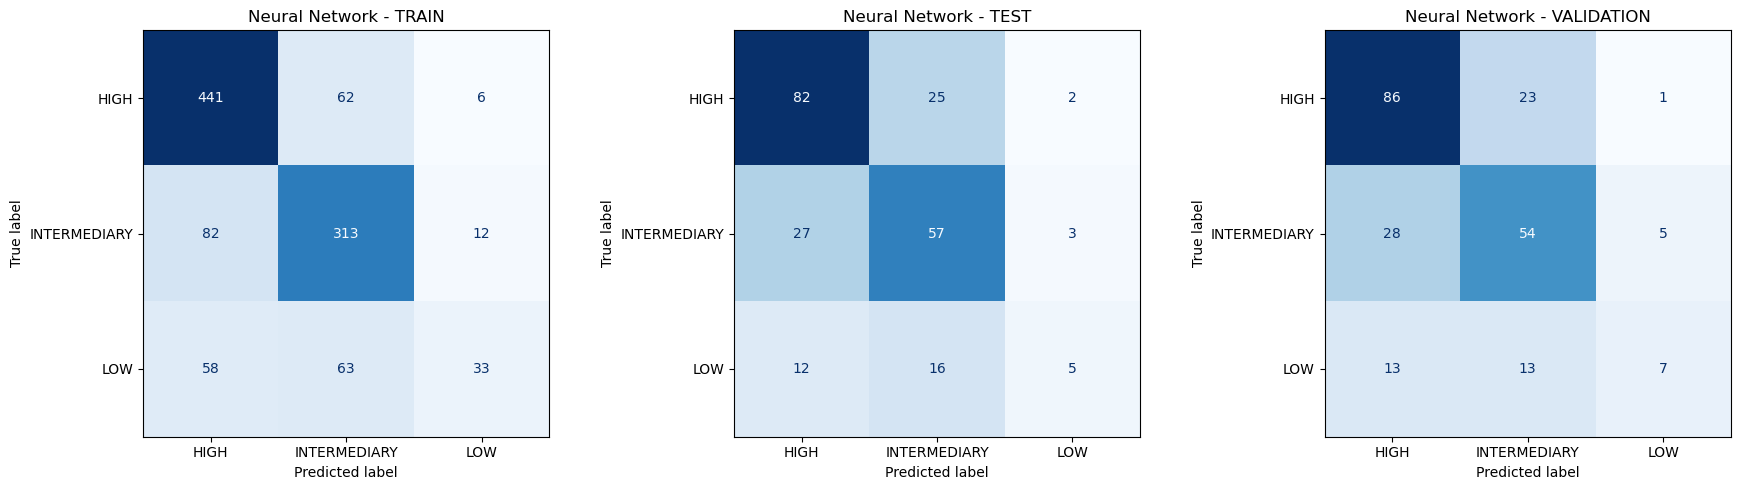

In [60]:
best_name = max(results, key=results.get)

best_cfg = next(c for c in configs if c[0] == best_name)

_, layers, lr, iters = best_cfg

best_model = MLPClassifier(
    hidden_layer_sizes=(64,32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.01,
    max_iter=500,
    early_stopping=True,
    random_state=42
)

best_model.fit(X_train_scaled, y_train_enc)

y_pred_train = best_model.predict(X_train_scaled)
y_pred_test = best_model.predict(X_test_scaled)
y_pred_val = best_model.predict(X_val_scaled)

evaluate("TRAIN", y_train_enc, y_pred_train)
evaluate("TEST", y_test_enc, y_pred_test)
evaluate("VALIDATION", y_val_enc, y_pred_val)

labels = ['HIGH', 'INTERMEDIARY', 'LOW']

cm_train = confusion_matrix(y_train_enc, y_pred_train, labels=[0,1,2])
cm_test = confusion_matrix(y_test_enc, y_pred_test, labels=[0,1,2])
cm_val = confusion_matrix(y_val_enc, y_pred_val, labels=[0,1,2])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, cm, title in zip(
    axes,
    [cm_train, cm_test, cm_val],
    ["TRAIN", "TEST", "VALIDATION"]
):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels
    )
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"Neural Network - {title}")

plt.tight_layout()
plt.show()

The best neural network model is retrained and evaluated on the validation set. The selected configuration achieves an accuracy of approximately 0.64, showing good performance for the HIGH class but continued difficulty in correctly identifying LOW cases, which are often misclassified as INTERMEDIARY. This indicates remaining challenges due to class overlap and imbalance.

#### 6.6 Addressing Class Imbalance

In [61]:
print(pd.Series(y_train).value_counts())

CVD Risk Level
HIGH            509
INTERMEDIARY    407
LOW             154
Name: count, dtype: int64


In [62]:
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

In [63]:
print(pd.Series(y_train_res).value_counts())

CVD Risk Level
INTERMEDIARY    509
HIGH            509
LOW             509
Name: count, dtype: int64


#### 6.6.1 KNN

In [64]:
model = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')

In [65]:
model.fit(X_train_res, y_train_res)

KNeighborsClassifier(metric='euclidean', weights='distance')

In [66]:
y_predicted_train = model.predict(X_train_res)
y_predicted_test = model.predict(X_test_scaled)
y_predicted_val = model.predict(X_val_scaled)

evaluate("TRAIN", y_train_res, y_predicted_train)
evaluate("TEST", y_test, y_predicted_test)
evaluate("VALIDATION", y_val, y_predicted_val)


TRAIN RESULTS
Accuracy: 1.0000
              precision    recall  f1-score   support

        HIGH       1.00      1.00      1.00       509
INTERMEDIARY       1.00      1.00      1.00       509
         LOW       1.00      1.00      1.00       509

    accuracy                           1.00      1527
   macro avg       1.00      1.00      1.00      1527
weighted avg       1.00      1.00      1.00      1527


TEST RESULTS
Accuracy: 0.5764
              precision    recall  f1-score   support

        HIGH       0.74      0.62      0.68       109
INTERMEDIARY       0.65      0.59      0.62        87
         LOW       0.22      0.39      0.28        33

    accuracy                           0.58       229
   macro avg       0.54      0.53      0.53       229
weighted avg       0.63      0.58      0.60       229


VALIDATION RESULTS
Accuracy: 0.5826
              precision    recall  f1-score   support

        HIGH       0.70      0.55      0.62       110
INTERMEDIARY       0.58      

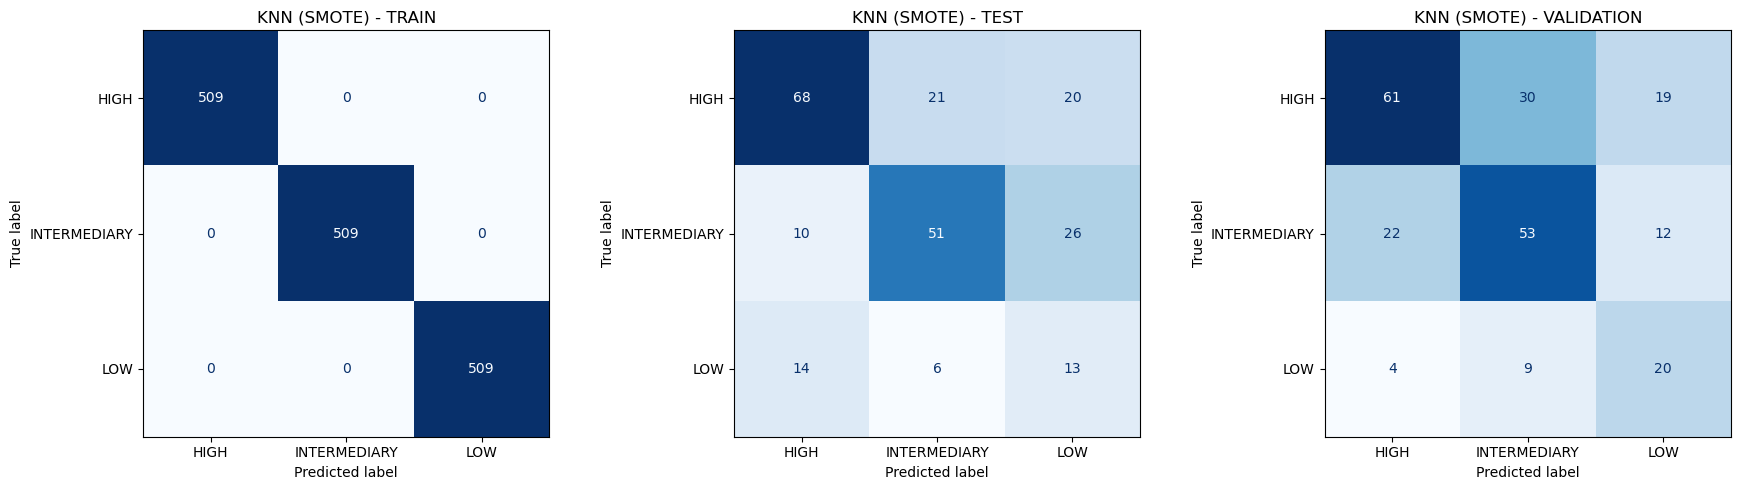

In [67]:
cm_train = confusion_matrix(y_train_res, y_predicted_train)
cm_test = confusion_matrix(y_test, y_predicted_test)
cm_val = confusion_matrix(y_val, y_predicted_val)

labels = ['HIGH', 'INTERMEDIARY', 'LOW']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, cm, title in zip(
    axes,
    [cm_train, cm_test, cm_val],
    ["TRAIN", "TEST", "VALIDATION"]
):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"KNN (SMOTE) - {title}")

plt.tight_layout()
plt.show()

#### 6.6.2 Logistic Regression

In [68]:
model = SGDClassifier(
    loss='log_loss',
    alpha=0.0001,      
    max_iter=2000,
    tol=1e-4,
    class_weight='balanced',
    random_state=42
)

In [69]:
model.fit(X_train_res, y_train_res)

SGDClassifier(class_weight='balanced', loss='log_loss', max_iter=2000,
              random_state=42, tol=0.0001)

In [70]:
y_predicted_train = model.predict(X_train_res)
y_predicted_test = model.predict(X_test_scaled)
y_predicted_val = model.predict(X_val_scaled)

evaluate("TRAIN", y_train_res, y_predicted_train)
evaluate("TEST", y_test, y_predicted_test)
evaluate("VALIDATION", y_val, y_predicted_val)


TRAIN RESULTS
Accuracy: 0.5409
              precision    recall  f1-score   support

        HIGH       0.60      0.69      0.64       509
INTERMEDIARY       0.49      0.70      0.58       509
         LOW       0.55      0.23      0.33       509

    accuracy                           0.54      1527
   macro avg       0.55      0.54      0.52      1527
weighted avg       0.55      0.54      0.52      1527


TEST RESULTS
Accuracy: 0.5721
              precision    recall  f1-score   support

        HIGH       0.72      0.62      0.67       109
INTERMEDIARY       0.52      0.62      0.57        87
         LOW       0.29      0.27      0.28        33

    accuracy                           0.57       229
   macro avg       0.51      0.51      0.51       229
weighted avg       0.58      0.57      0.57       229


VALIDATION RESULTS
Accuracy: 0.5565
              precision    recall  f1-score   support

        HIGH       0.66      0.60      0.63       110
INTERMEDIARY       0.54      

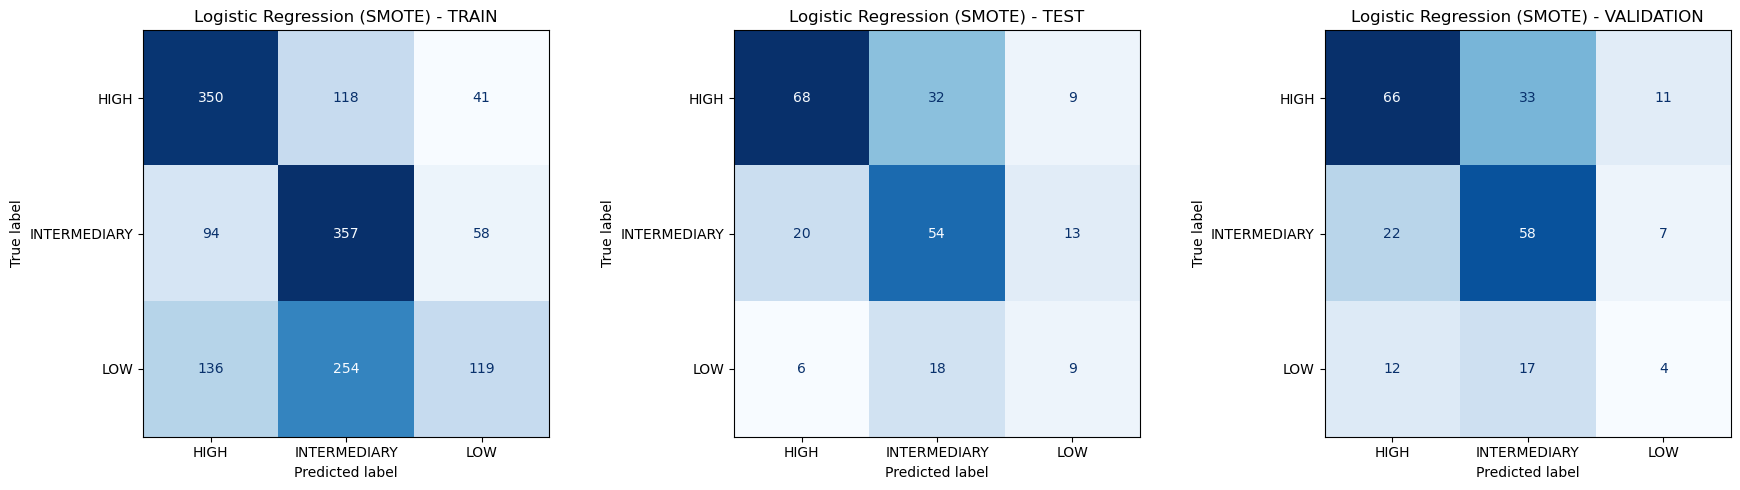

In [71]:
cm_train = confusion_matrix(y_train_res, y_predicted_train)
cm_test = confusion_matrix(y_test, y_predicted_test)
cm_val = confusion_matrix(y_val, y_predicted_val)

labels = ['HIGH', 'INTERMEDIARY', 'LOW']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, cm, title in zip(
    axes,
    [cm_train, cm_test, cm_val],
    ["TRAIN", "TEST", "VALIDATION"]
):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"Logistic Regression (SMOTE) - {title}")

plt.tight_layout()
plt.show()

#### 6.6.3 Neural Network

In [72]:
# Encode labels for Neural Network
label_map = {
    'HIGH': 0,
    'INTERMEDIARY': 1,
    'LOW': 2
}

y_train_res_enc = y_train_res.map(label_map)
y_val_enc = y_val.map(label_map)
y_test_enc = y_test.map(label_map)

In [73]:
model.fit(X_train_res, y_train_res_enc)

SGDClassifier(class_weight='balanced', loss='log_loss', max_iter=2000,
              random_state=42, tol=0.0001)

In [74]:
y_pred_train = model.predict(X_train_res)
y_pred_test = model.predict(X_test_scaled)
y_pred_val = model.predict(X_val_scaled)

In [75]:
evaluate("TRAIN", y_train_res_enc, y_pred_train)
evaluate("TEST", y_test_enc, y_pred_test)
evaluate("VALIDATION", y_val_enc, y_pred_val)


TRAIN RESULTS
Accuracy: 0.5409
              precision    recall  f1-score   support

           0       0.60      0.69      0.64       509
           1       0.49      0.70      0.58       509
           2       0.55      0.23      0.33       509

    accuracy                           0.54      1527
   macro avg       0.55      0.54      0.52      1527
weighted avg       0.55      0.54      0.52      1527


TEST RESULTS
Accuracy: 0.5721
              precision    recall  f1-score   support

           0       0.72      0.62      0.67       109
           1       0.52      0.62      0.57        87
           2       0.29      0.27      0.28        33

    accuracy                           0.57       229
   macro avg       0.51      0.51      0.51       229
weighted avg       0.58      0.57      0.57       229


VALIDATION RESULTS
Accuracy: 0.5565
              precision    recall  f1-score   support

           0       0.66      0.60      0.63       110
           1       0.54      

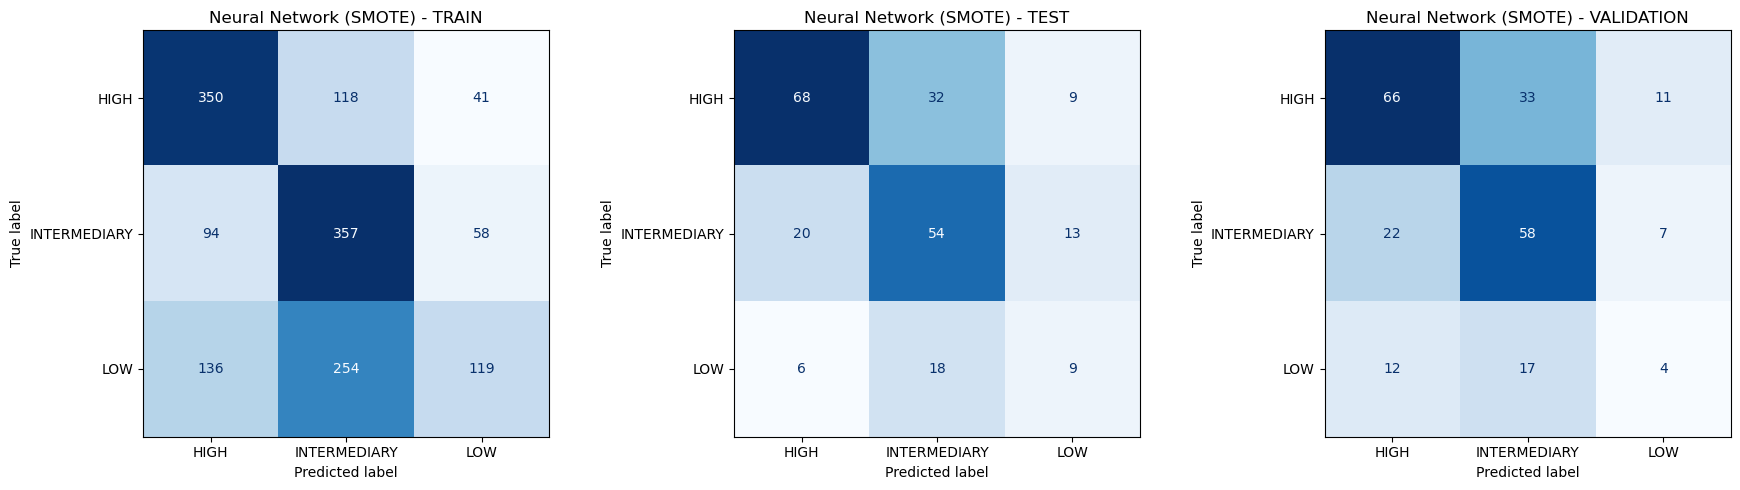

In [76]:
labels = ['HIGH', 'INTERMEDIARY', 'LOW']

cm_train = confusion_matrix(y_train_res_enc, y_pred_train, labels=[0,1,2])
cm_test = confusion_matrix(y_test_enc, y_pred_test, labels=[0,1,2])
cm_val = confusion_matrix(y_val_enc, y_pred_val, labels=[0,1,2])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, cm, title in zip(
    axes,
    [cm_train, cm_test, cm_val],
    ["TRAIN", "TEST", "VALIDATION"]
):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels
    )
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"Neural Network (SMOTE) - {title}")

plt.tight_layout()
plt.show()

### 7. Model Tuning

In this section, hyperparameter tuning is performed to improve the performance of the selected models: K-Nearest Neighbors (KNN), Logistic Regression (SGDClassifier), and Neural Network (MLPClassifier).

We use **GridSearchCV with cross-validation** to systematically explore combinations of hyperparameters and identify the optimal configuration for each model. Grid search is chosen because it evaluates all possible combinations within the defined parameter space, ensuring a thorough and reproducible search process.

To better account for class imbalance in the dataset, **macro-averaged F1-score (`f1_macro`)** is used as the evaluation metric. This ensures that all classes, including the minority class (LOW), are given equal importance during model selection.

#### 7.0.1 KNN Hyperparameter Tuning

For the KNN model, the following hyperparameters are tuned:

- **n_neighbors**: Number of nearest neighbors used for classification. Smaller values may capture local patterns but risk overfitting, while larger values improve generalization.
- **weights**: Determines whether all neighbors contribute equally (`uniform`) or closer neighbors have more influence (`distance`).
- **metric**: Distance measure used to compute similarity between samples (e.g., Euclidean or Manhattan).

A 5-fold cross-validation strategy is used to evaluate each parameter combination.

In [77]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn = KNeighborsClassifier()

grid_knn = GridSearchCV(
    knn,
    param_grid_knn,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_knn.fit(X_train_scaled, y_train)
best_knn = grid_knn.best_estimator_

print("Best KNN Params:", grid_knn.best_params_)
print("Best CV Score:", grid_knn.best_score_)

Best KNN Params: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'}
Best CV Score: 0.5307155416467774


The best KNN configuration found was:
- **n_neighbors = 5**
- **weights = 'distance'**
- **metric = 'euclidean'**

This configuration achieved a cross-validation F1-score of **0.5307**.

This suggests that giving more importance to closer neighbors improves classification performance, particularly in handling class boundaries. However, the relatively moderate F1-score indicates that KNN may still struggle with class imbalance and generalization.

#### 7.0.2 Logistic Regression (SGDClassifier) Hyperparameter Tuning

For Logistic Regression, implemented using SGDClassifier, the following hyperparameters are tuned:

- **alpha**: Controls regularization strength; higher values prevent overfitting.
- **max_iter**: Number of training iterations.
- **learning_rate**: Strategy for updating weights during training.
- **eta0**: Initial learning rate.
- **penalty**: Type of regularization (L2 or ElasticNet).
- **class_weight**: Adjusts weights to handle class imbalance.

These parameters directly influence convergence, generalization, and the model’s ability to handle imbalanced data.

In [78]:
param_grid_sgd = {
    'alpha': [0.00001, 0.0001, 0.001, 0.01], 
    'max_iter': [1000, 2000, 3000],
    'learning_rate': ['optimal', 'adaptive'],
    'eta0': [0.001, 0.01], 
    'penalty': ['l2', 'elasticnet'],
    'class_weight': [None, 'balanced']
}

sgd = SGDClassifier(
    loss='log_loss',  
    random_state=42
)

grid_sgd = GridSearchCV(
    sgd,
    param_grid_sgd,
    cv=5,
    scoring='f1_macro', 
    n_jobs=-1
)

grid_sgd.fit(X_train_scaled, y_train)
best_sgd = grid_sgd.best_estimator_

print("Best SGD Logistic Params:", grid_sgd.best_params_)
print("Best CV Score:", grid_sgd.best_score_)

Best SGD Logistic Params: {'alpha': 1e-05, 'class_weight': 'balanced', 'eta0': 0.001, 'learning_rate': 'adaptive', 'max_iter': 1000, 'penalty': 'l2'}
Best CV Score: 0.5466542427183386


The best Logistic Regression configuration found was:
- **alpha = 1e-05**
- **learning_rate = 'adaptive'**
- **eta0 = 0.001**
- **max_iter = 1000**
- **penalty = 'l2'**
- **class_weight = 'balanced'**

This configuration achieved a cross-validation F1-score of **0.5467**.

The inclusion of **class_weight='balanced'** indicates that adjusting for class imbalance improves performance. The adaptive learning rate allows the model to adjust updates dynamically, improving convergence stability.

#### 7.0.3 Neural Network Hyperparameter Tuning

For the Neural Network (MLPClassifier), the following hyperparameters are tuned:

- **hidden_layer_sizes**: Defines the number and size of hidden layers, controlling model complexity.
- **learning_rate_init**: Initial learning rate for weight updates.
- **max_iter**: Number of training iterations.

Due to the higher computational cost of neural networks, a smaller 3-fold cross-validation is used.

In [ ]:
param_grid_nn = {
    'hidden_layer_sizes': [(16,), (32,), (64,32)],
    'learning_rate_init': [0.0005, 0.001],
    'max_iter': [1000, 1500],
}

mlp = MLPClassifier(
    activation='relu',
    solver='adam',
    random_state=42
)

grid_nn = GridSearchCV(
    mlp,
    param_grid_nn,
    cv=3, 
    scoring='f1_macro',
    n_jobs=-1
)

grid_nn.fit(X_train_scaled, y_train_enc)
best_nn  = grid_nn.best_estimator_

print("Best NN Params:", grid_nn.best_params_)
print("Best CV Score:", grid_nn.best_score_)

Best NN Params: {'hidden_layer_sizes': (16,), 'learning_rate_init': 0.0005, 'max_iter': 1000}
Best CV Score: 0.5618012025289428


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


The best Neural Network configuration found was:
- **hidden_layer_sizes = (16,)**
- **learning_rate_init = 0.0005**
- **max_iter = 1000**

This configuration achieved the highest cross-validation F1-score of **0.5618** among all models.

This indicates that a simpler architecture (single hidden layer with fewer neurons) generalizes better for this dataset. The lower learning rate helps stabilize training, although the convergence warning suggests that the model may benefit from additional iterations or early stopping.

#### 7.0.4 Summary of Hyperparameter Tuning

From the hyperparameter tuning results:

- **Neural Network** achieved the highest cross-validation F1-score (**0.5618**), indicating the best overall balance across classes.
- **Logistic Regression** performed moderately well (**0.5467**) and showed robustness with class imbalance handling.
- **KNN** achieved the lowest F1-score (**0.5307**), suggesting limitations in generalization and sensitivity to class distribution.

These tuned models are used in the next section for detailed evaluation on training, test, and validation datasets.

#### 7.1 Evaluating Tuned Models

In this section, the performance of the tuned models—KNN, Logistic Regression (SGDClassifier), and Neural Network (MLPClassifier)—is evaluated on the **training, test, and validation datasets**.

Evaluating across these three datasets allows us to assess:
- **Training performance**, which indicates how well the model fits the data it was trained on.
- **Test performance**, which provides an estimate of generalization to unseen data.
- **Validation performance**, which is used for final model comparison and selection.

Each model is evaluated using the following metrics:
- **Accuracy**: Overall correctness of predictions.
- **Precision**: Proportion of correct positive predictions for each class.
- **Recall**: Ability of the model to correctly identify instances of each class.
- **F1-score**: Harmonic mean of precision and recall, providing a balanced measure of performance.

Additionally, **confusion matrices** are used to visualize how predictions are distributed across classes, allowing for deeper insight into misclassification patterns.

This evaluation is particularly important due to the **class imbalance present in the dataset**, where the LOW risk class has significantly fewer samples. As a result, metrics such as precision, recall, and F1-score are emphasized over accuracy to ensure fair assessment across all classes.

#### 7.1.1 KNN

In [80]:
y_pred_knn_train = best_knn.predict(X_train_scaled)
y_pred_knn_test = best_knn.predict(X_test_scaled)
y_pred_knn_val = best_knn.predict(X_val_scaled)

evaluate("KNN TRAIN", y_train, y_pred_knn_train)
evaluate("KNN TEST", y_test, y_pred_knn_test)
evaluate("KNN VALIDATION", y_val, y_pred_knn_val)


KNN TRAIN RESULTS
Accuracy: 1.0000
              precision    recall  f1-score   support

        HIGH       1.00      1.00      1.00       509
INTERMEDIARY       1.00      1.00      1.00       407
         LOW       1.00      1.00      1.00       154

    accuracy                           1.00      1070
   macro avg       1.00      1.00      1.00      1070
weighted avg       1.00      1.00      1.00      1070


KNN TEST RESULTS
Accuracy: 0.6638
              precision    recall  f1-score   support

        HIGH       0.70      0.80      0.74       109
INTERMEDIARY       0.68      0.72      0.70        87
         LOW       0.17      0.06      0.09        33

    accuracy                           0.66       229
   macro avg       0.52      0.53      0.51       229
weighted avg       0.62      0.66      0.63       229


KNN VALIDATION RESULTS
Accuracy: 0.6043
              precision    recall  f1-score   support

        HIGH       0.67      0.69      0.68       110
INTERMEDIARY     

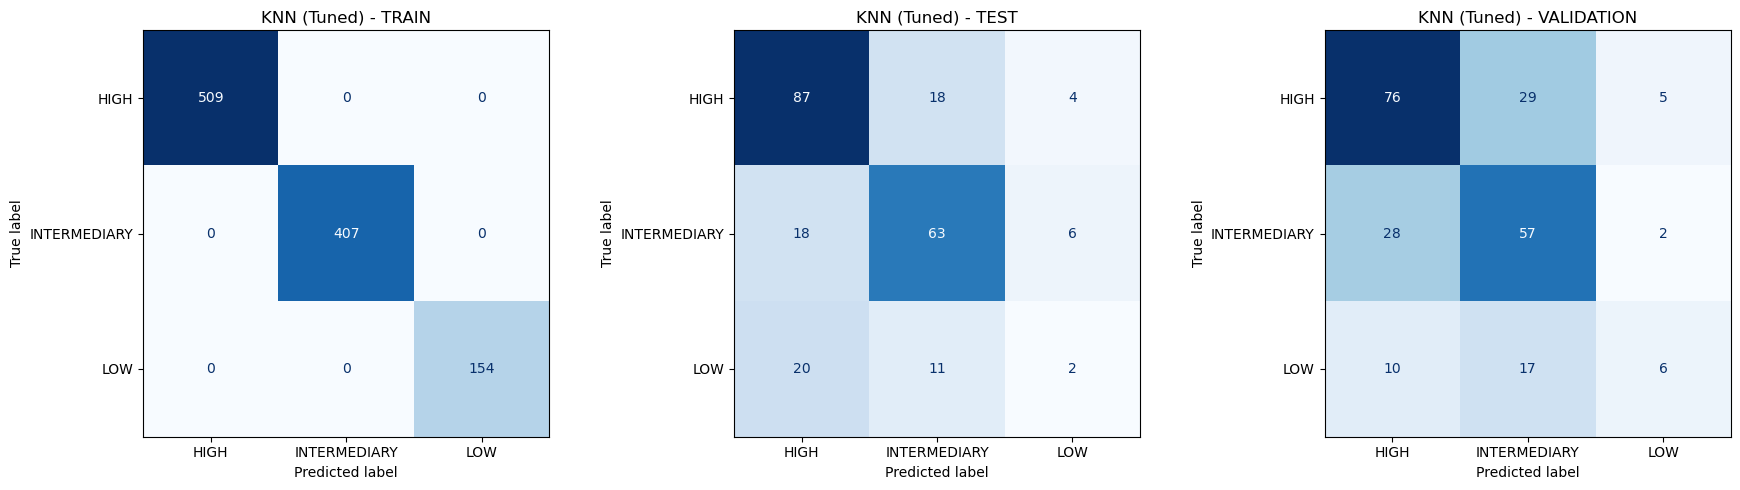

In [81]:
labels = ['HIGH','INTERMEDIARY','LOW']

cm_train = confusion_matrix(y_train, y_pred_knn_train, labels=labels)
cm_test = confusion_matrix(y_test, y_pred_knn_test, labels=labels)
cm_val = confusion_matrix(y_val, y_pred_knn_val, labels=labels)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, cm, title in zip(
    axes,
    [cm_train, cm_test, cm_val],
    ["TRAIN", "TEST", "VALIDATION"]
):
    disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"KNN (Tuned) - {title}")

plt.tight_layout()
plt.show()

The tuned KNN model achieved perfect training performance, with accuracy, precision, recall, and F1-score all equal to 1.00 across all classes. While this indicates complete learning of the training data, it is a clear sign of overfitting, as the model memorizes rather than generalizes.

This is confirmed by the drop in performance:

- Test Accuracy: 66.38%
- Validation Accuracy: 60.43%

From the classification metrics:

- HIGH class: Strong performance with precision (0.70–0.67) and recall (0.80–0.69), resulting in high F1-scores (~0.68–0.74).
- INTERMEDIARY class: Moderate and stable performance with F1-scores (~0.60–0.70).
- LOW class: Very poor performance, especially in the test set:
    - Recall as low as 0.06
    - F1-score as low as 0.09

This indicates that the model rarely correctly identifies LOW-risk instances, leading to high false negatives.

The confusion matrices reinforce this:

- LOW instances are frequently misclassified as HIGH or INTERMEDIARY.
- The model is biased toward majority classes.

Overall, KNN demonstrates:

- Severe overfitting
- Poor minority class detection
- Weak generalization

#### 7.1.2 Logistic Regression

In [82]:
y_pred_sgd_train = best_sgd.predict(X_train_scaled)
y_pred_sgd_test = best_sgd.predict(X_test_scaled)
y_pred_sgd_val = best_sgd.predict(X_val_scaled)

evaluate("Logistic Regression TRAIN", y_train, y_pred_sgd_train)
evaluate("Logistic Regression TEST", y_test, y_pred_sgd_test)
evaluate("Logistic Regression VALIDATION", y_val, y_pred_sgd_val)


Logistic Regression TRAIN RESULTS
Accuracy: 0.6495
              precision    recall  f1-score   support

        HIGH       0.72      0.75      0.74       509
INTERMEDIARY       0.64      0.69      0.66       407
         LOW       0.31      0.21      0.25       154

    accuracy                           0.65      1070
   macro avg       0.56      0.55      0.55      1070
weighted avg       0.63      0.65      0.64      1070


Logistic Regression TEST RESULTS
Accuracy: 0.6376
              precision    recall  f1-score   support

        HIGH       0.71      0.74      0.73       109
INTERMEDIARY       0.63      0.66      0.64        87
         LOW       0.33      0.24      0.28        33

    accuracy                           0.64       229
   macro avg       0.56      0.55      0.55       229
weighted avg       0.62      0.64      0.63       229


Logistic Regression VALIDATION RESULTS
Accuracy: 0.5957
              precision    recall  f1-score   support

        HIGH       0.69

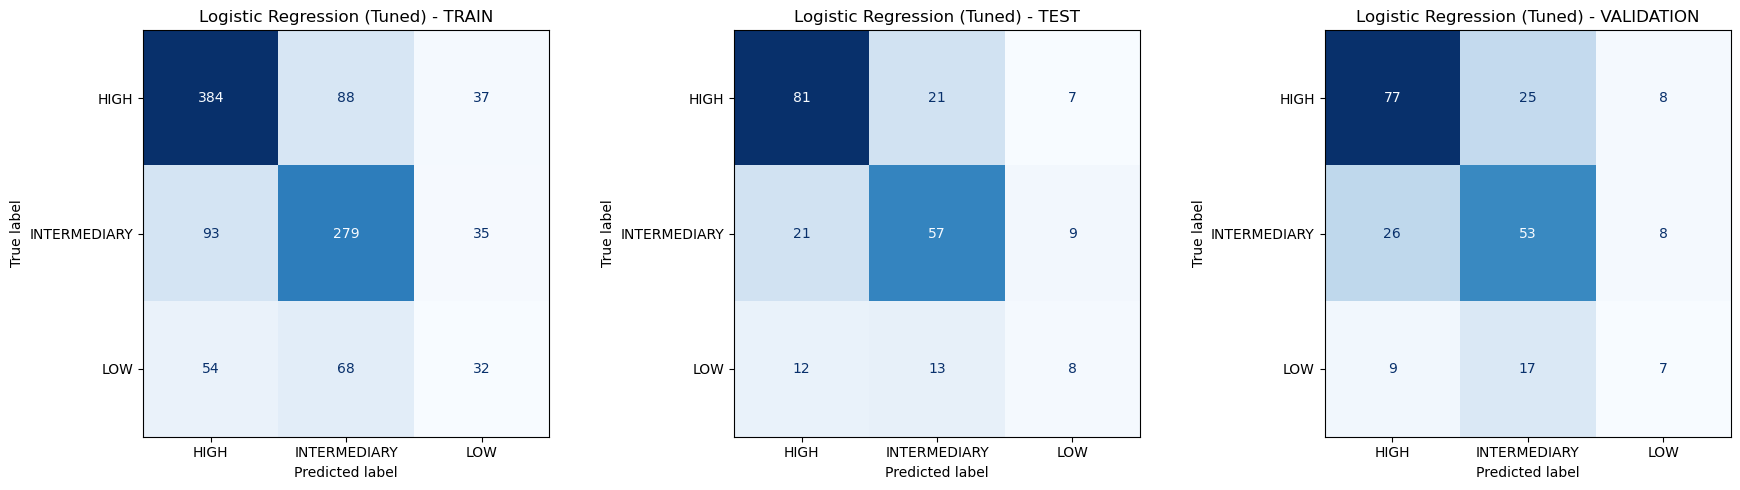

In [83]:
cm_train = confusion_matrix(y_train, y_pred_sgd_train, labels=labels)
cm_test = confusion_matrix(y_test, y_pred_sgd_test, labels=labels)
cm_val = confusion_matrix(y_val, y_pred_sgd_val, labels=labels)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, cm, title in zip(
    axes,
    [cm_train, cm_test, cm_val],
    ["TRAIN", "TEST", "VALIDATION"]
):
    disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"Logistic Regression (Tuned) - {title}")

plt.tight_layout()
plt.show()

The tuned Logistic Regression model shows consistent performance across training, test, and validation sets, indicating strong generalization:

- Train Accuracy: 64.95%
- Test Accuracy: 63.76%
- Validation Accuracy: 59.57%

From the classification metrics:

- HIGH class:
    - Precision: ~0.69–0.72
    - Recall: ~0.70–0.75
    - F1-score: ~0.69–0.74
This class is well learned and consistently predicted.

- INTERMEDIARY class:
    - Precision & recall around ~0.56–0.69
    - F1-score: ~0.58–0.66
Balanced but slightly lower than HIGH.

- LOW class:
    - Precision: ~0.30–0.33
    - Recall: ~0.21–0.24
    - F1-score: ~0.25–0.28
Still the weakest class.

The relatively low recall for LOW indicates that many LOW-risk instances are not detected, while low precision indicates incorrect LOW predictions.

From the confusion matrices:

- Misclassifications for LOW are spread across HIGH and INTERMEDIARY.
- However, errors are more evenly distributed compared to KNN.

Overall, Logistic Regression:

- Shows stable precision-recall balance
- Has minimal overfitting
- Provides a strong baseline model

#### 7.1.3 Neural Network

In [84]:
y_pred_nn_train = best_nn.predict(X_train_scaled)
y_pred_nn_test = best_nn.predict(X_test_scaled)
y_pred_nn_val = best_nn.predict(X_val_scaled)

evaluate("NN TRAIN", y_train_enc, y_pred_nn_train)
evaluate("NN TEST", y_test_enc, y_pred_nn_test)
evaluate("NN VALIDATION", y_val_enc, y_pred_nn_val)


NN TRAIN RESULTS
Accuracy: 0.7374
              precision    recall  f1-score   support

           0       0.77      0.83      0.80       509
           1       0.73      0.77      0.75       407
           2       0.58      0.34      0.43       154

    accuracy                           0.74      1070
   macro avg       0.69      0.65      0.66      1070
weighted avg       0.73      0.74      0.73      1070


NN TEST RESULTS
Accuracy: 0.6201
              precision    recall  f1-score   support

           0       0.68      0.75      0.71       109
           1       0.62      0.63      0.62        87
           2       0.26      0.15      0.19        33

    accuracy                           0.62       229
   macro avg       0.52      0.51      0.51       229
weighted avg       0.60      0.62      0.60       229


NN VALIDATION RESULTS
Accuracy: 0.6304
              precision    recall  f1-score   support

           0       0.69      0.74      0.71       110
           1       0

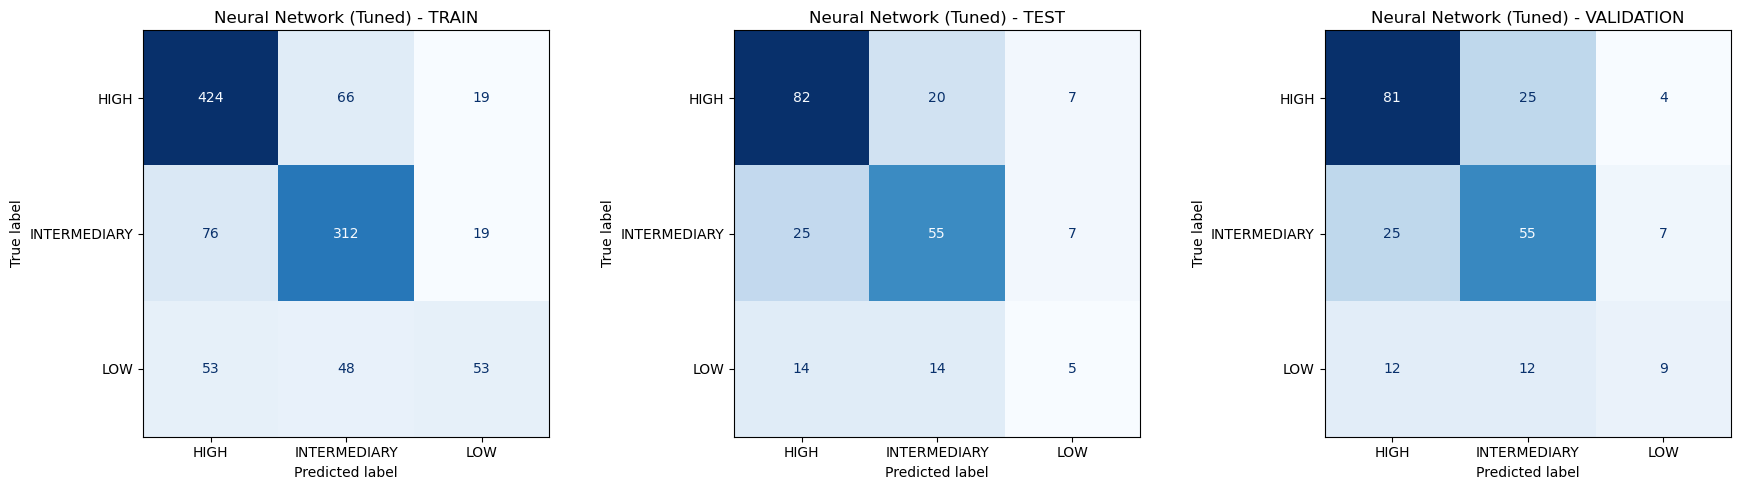

In [85]:
cm_train = confusion_matrix(y_train_enc, y_pred_nn_train, labels=[0,1,2])
cm_test = confusion_matrix(y_test_enc, y_pred_nn_test, labels=[0,1,2])
cm_val = confusion_matrix(y_val_enc, y_pred_nn_val, labels=[0,1,2])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, cm, title in zip(
    axes,
    [cm_train, cm_test, cm_val],
    ["TRAIN", "TEST", "VALIDATION"]
):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['HIGH','INTERMEDIARY','LOW']
    )
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"Neural Network (Tuned) - {title}")

plt.tight_layout()
plt.show()

The tuned Neural Network achieved the highest overall validation performance, with:

- Train Accuracy: 73.74%
- Test Accuracy: 62.01%
- Validation Accuracy: 63.04%

This indicates moderate overfitting, but better generalization than KNN.

From the classification metrics:

- HIGH class:
    - Precision: ~0.68–0.77
    - Recall: ~0.74–0.83
    - F1-score: ~0.71–0.80
Strong and consistent performance.

- INTERMEDIARY class:
    - Precision & recall: ~0.60–0.77
    - F1-score: ~0.61–0.75
Stable and well-balanced.

- LOW class:
    - Precision: up to 0.45 (validation)
    - Recall: up to 0.27 (validation)
    - F1-score: up to 0.34

Compared to other models, the Neural Network shows:

- Improved recall for LOW class
- Better F1-score balance across classes

From the confusion matrices:

- Fewer LOW samples are completely ignored compared to KNN
- Still some misclassification into HIGH and INTERMEDIARY, but less extreme

This indicates the Neural Network is better at learning non-linear relationships, improving minority class detection.

#### 7.2 Summary of Tuned Models

Comparing the tuned models based on accuracy, precision, recall, and F1-score:

- KNN
    - Highest training accuracy (1.00) but severe overfitting
    - Poor recall and F1-score for LOW class
    - Weak generalization
- Logistic Regression
    - Most stable model across all datasets
    - Balanced precision and recall
    - Limited ability to improve LOW class performance
- Neural Network
    - Highest validation accuracy (63.04%)
    - Best F1-score balance across classes
    - Improved detection of LOW class

Across all models:

- HIGH class consistently achieved the best performance
- INTERMEDIARY class showed moderate stability
- LOW class had the lowest recall and F1-score due to class imbalance

The LOW class consistently suffers from:

- Low recall > many missed predictions
- Low precision > incorrect predictions

This indicates that class imbalance remains the primary limitation of the dataset.